/tmp/ipykernel_934028/4108136446.py:88: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


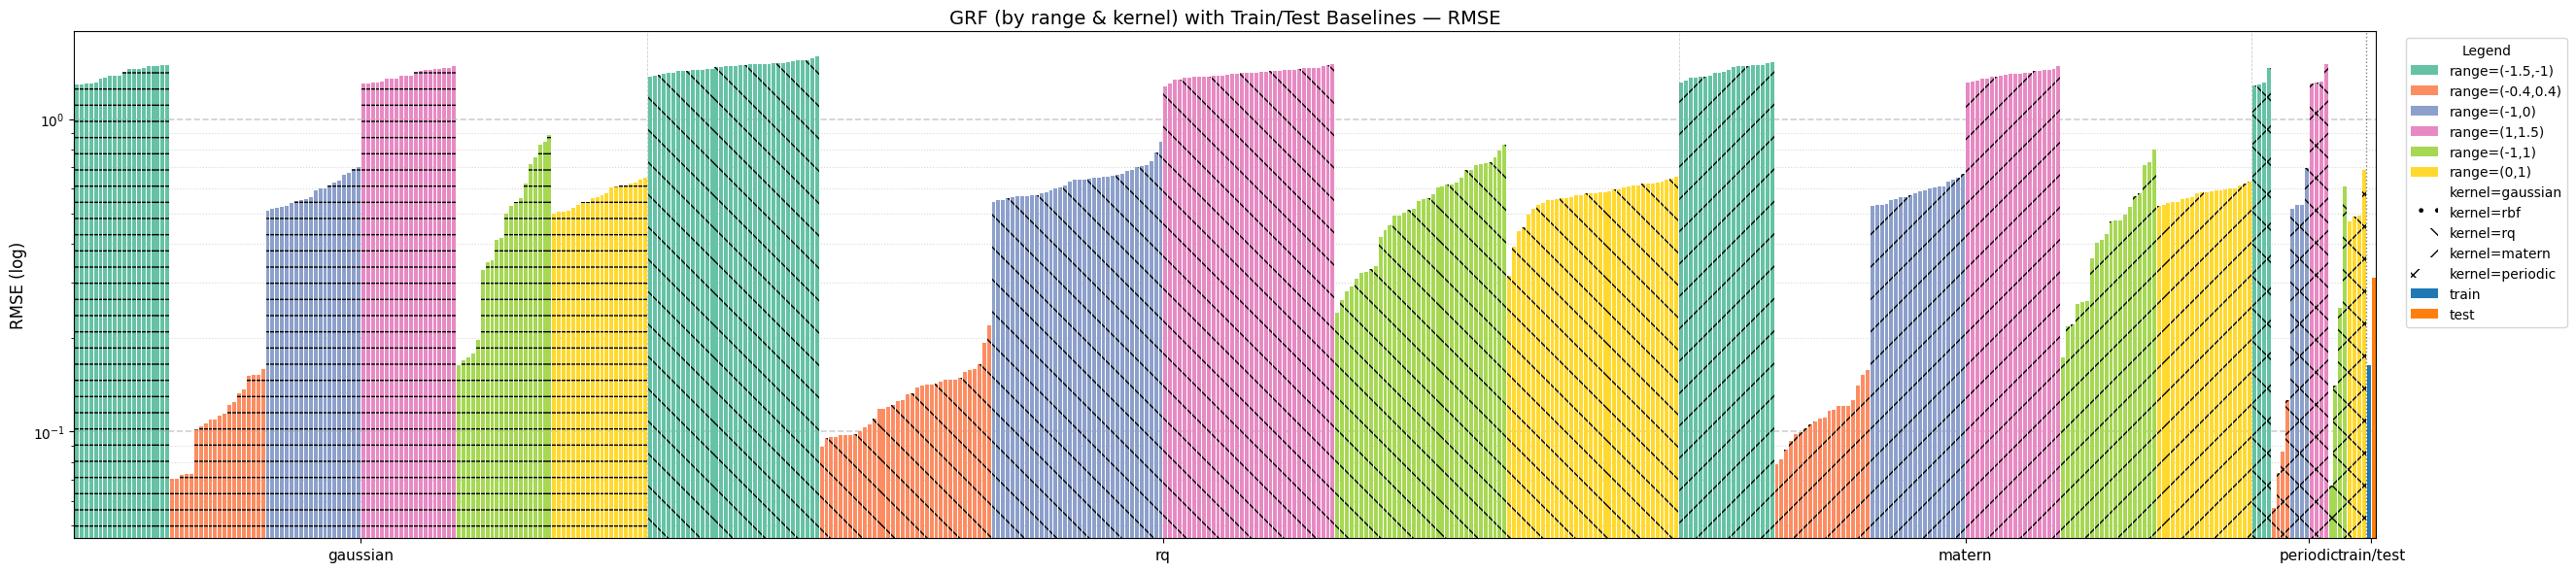

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

# ---------- 读 GRF CSV -> 只保留 family=GRF ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)
df_grf = df_grf[df_grf["family"] == "GRF"].copy()

# 排序：kernel -> range -> rmse
kernel_order = ["gaussian", "rbf", "rq", "matern", "periodic", "other"]
all_ranges = df_grf["range_label"].dropna().unique().tolist()
range_order  = all_ranges

def sort_key(row):
    k = row["kernel"]
    r = row["range_label"]
    ko = kernel_order.index(k) if k in kernel_order else len(kernel_order)
    ro = range_order.index(r) if r in range_order else len(range_order)
    rmse = float(row["rmse_mean"]) if pd.notna(row["rmse_mean"]) else np.inf
    return (ko, ro, rmse)

df_grf = (
    df_grf.assign(__sort=df_grf.apply(sort_key, axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True)
)

# 颜色：range -> 色相
palette = plt.cm.Set2.colors if len(all_ranges) <= 8 else plt.cm.tab20.colors
range2color = {rg: palette[i % len(palette)] for i, rg in enumerate(all_ranges)}
def color_by_range(row):
    return range2color.get(row["range_label"], (0.7, 0.7, 0.7))

# 纹理：kernel -> hatch
hatch_map = {
    "gaussian": "-",
    "rbf": ".",
    "rq": "\\",
    "matern": "/",
    "periodic": "x",
    "other": None,
}

# ---------- 读 train/test CSV -> 取两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

# 只要 rmse_mean 与 N
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")

# 构造与 GRF 相同的列接口（占位）
df_base["kernel"] = "baseline"
df_base["range_label"] = "baseline"
df_base["__is_baseline"] = True
df_grf["__is_baseline"] = False

# 合并：GRF 在前，baseline 两根柱接在最后
df_all = pd.concat([df_grf, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- kernel 分块刻度（只基于 GRF 部分） ----------
def kernel_ticks_and_boundaries(sub_df):
    tick_pos, tick_lab, boundaries = [], [], []
    last_end = None
    arr = sub_df["kernel"].values
    for k in kernel_order:
        idx = np.where(arr == k)[0]
        if idx.size == 0:
            continue
        start, end = int(idx[0]), int(idx[-1])
        tick_pos.append((start + end) / 2.0)
        tick_lab.append(k)
        if last_end is not None:
            boundaries.append(last_end + 0.5)
        last_end = end
    return tick_pos, tick_lab, boundaries

df_grf_only = df_all[~df_all["__is_baseline"]].reset_index(drop=True)
tick_pos, tick_lab, boundaries = kernel_ticks_and_boundaries(df_grf_only)

# baseline 的两根柱位置
baseline_start = len(df_grf_only)
baseline_count = int(df_all["__is_baseline"].sum())
baseline_mid = baseline_start + (baseline_count - 1) / 2.0
# 在 x 轴补一个 'train/test' 的大块标注
tick_pos_combined = tick_pos + ([baseline_mid] if baseline_count > 0 else [])
tick_lab_combined = tick_lab + (["train/test"] if baseline_count > 0 else [])

# ---------- 画图（单轴） ----------
fig_w = max(20, int(len(df_all) * 0.06))
fig, ax = plt.subplots(figsize=(fig_w, 6))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# 颜色：GRF 用 range 色；baseline 用固定色
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}
colors = []
hatches = []
for _, r in df_all.iterrows():
    if r["__is_baseline"]:
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
        hatches.append(None)
    else:
        colors.append(color_by_range(r))
        hatches.append(hatch_map.get(r["kernel"], None))

bars = ax.bar(x, y, color=colors, edgecolor="black", linewidth=0.0)
for b, h in zip(bars, hatches):
    if h:
        b.set_hatch(h)

# 外观
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("GRF (by range & kernel) with Train/Test Baselines — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# x 轴稀疏刻度：各 kernel 的中点 + baseline 的中点
ax.set_xticks(tick_pos_combined)
ax.set_xticklabels(tick_lab_combined, fontsize=11)

# 分界线：kernel 块之间 + GRF 与 baseline 之间
for b in boundaries:
    ax.axvline(b, color="gray", lw=0.6, ls="--", alpha=0.4)
if baseline_count > 0:
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.5)

# ---------- 图例 ----------
legend_elements = []

# range（色相）— 只列 GRF 里出现的 range
for rg in all_ranges:
    legend_elements.append(Patch(facecolor=range2color[rg], edgecolor="none", label=rg))

# kernel（hatch）
for k, h in hatch_map.items():
    if not h:
        continue
    legend_elements.append(Patch(facecolor="white", edgecolor="black", hatch=h, label=f"kernel={k}", linewidth=0.0))

# baseline（train/test）
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))

ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_grf_with_train_test.png", dpi=200, bbox_inches="tight")


/tmp/ipykernel_934028/725671501.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


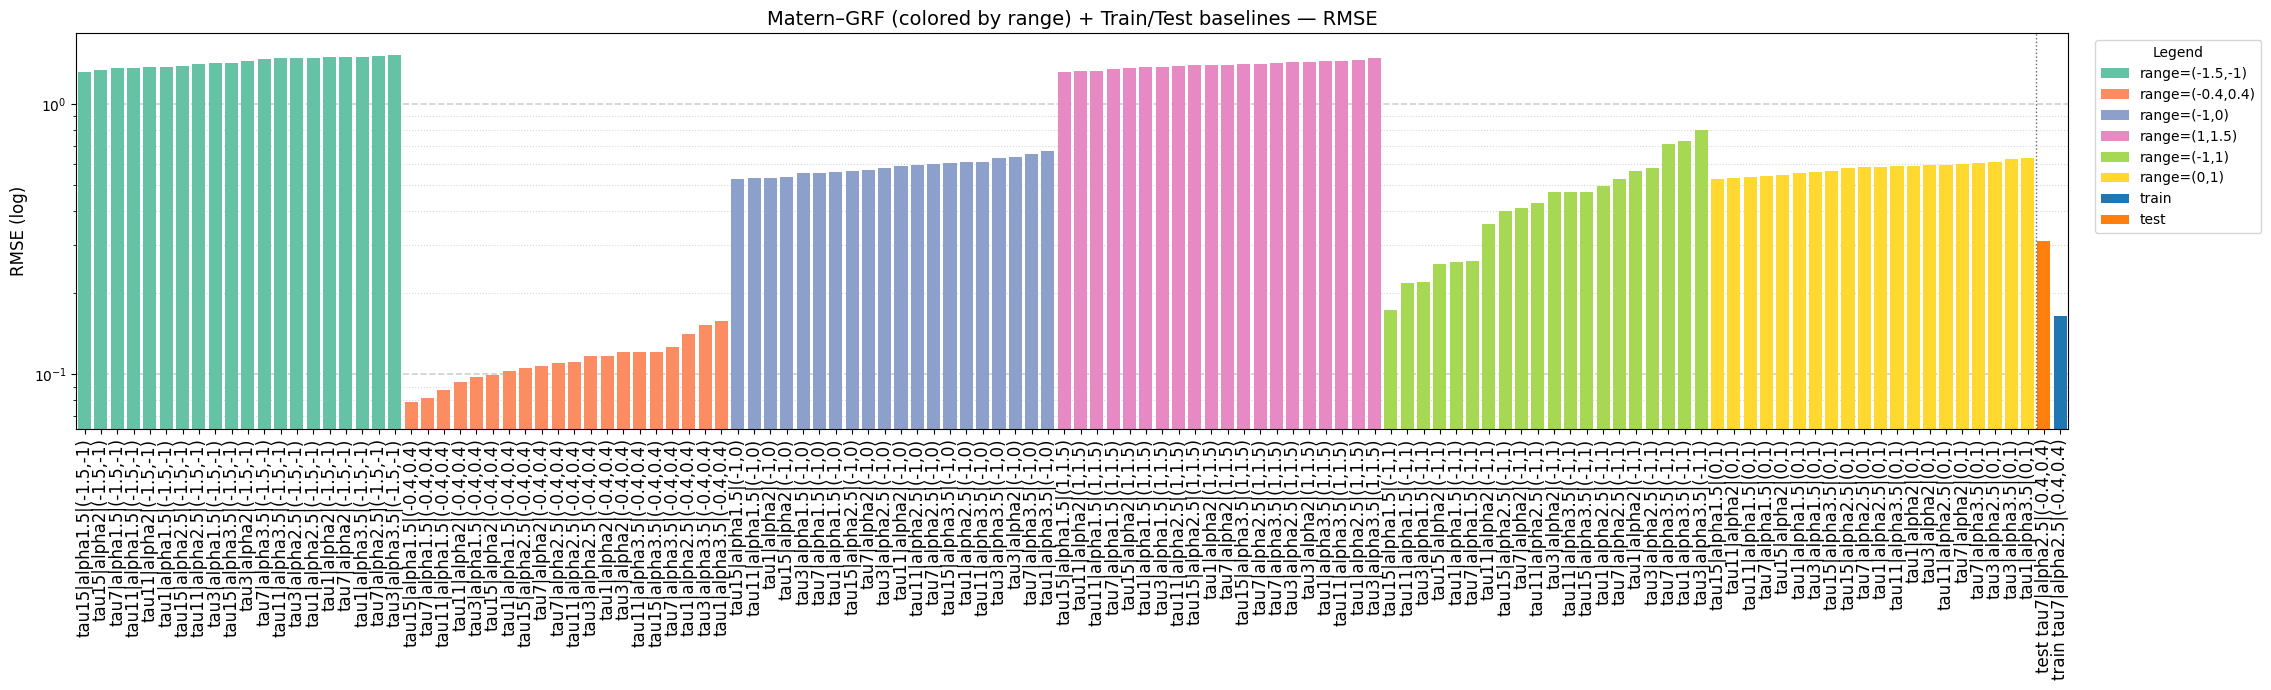

In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 只要不换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_alpha_tau(row):
    """优先用列值，否则从 dataset_name 兜底正则提取"""
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name", ""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

# ---------- 读 generalizability CSV -> 只保留 family=GRF & kernel=matern ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)

df_grf = df_grf[(df_grf["family"] == "GRF") & (df_grf["kernel"] == "matern")].copy()

# —— 每根柱子的“单行”标签（不再写 GRF/Matern，避免重复）——
def make_bar_label(row):
    a, t = get_alpha_tau(row)
    r    = row["range_label"].replace("range=", "")  # 简化显示
    return f"tau{t}|alpha{a}|{r}"

df_grf["bar_label"] = df_grf.apply(make_bar_label, axis=1)

# 颜色：range -> 色相
all_ranges = df_grf["range_label"].dropna().unique().tolist()
palette = plt.cm.Set2.colors if len(all_ranges) <= 8 else plt.cm.tab20.colors
range2color = {rg: palette[i % len(palette)] for i, rg in enumerate(all_ranges)}
def color_by_range(row):
    return range2color.get(row["range_label"], (0.7, 0.7, 0.7))

# 排序：可以按 range + rmse（或保持原顺序）——这里按 range 后 rmse
range_order = {rg:i for i,rg in enumerate(all_ranges)}
df_grf = (df_grf
          .assign(__sort=df_grf.apply(lambda r: (range_order.get(r["range_label"], 1e9),
                                                 float(r["rmse_mean"]) if pd.notna(r["rmse_mean"]) else np.inf), axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True))

# ---------- 读 train/test CSV -> 两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# 为 baseline 准备标签（单行）
def base_label(row):
    if row["split"] == "train":
        return TRAIN_DESC
    else:
        return TEST_DESC

df_base["bar_label"] = df_base.apply(base_label, axis=1)

# 合并：所有 Matern-GRF 在前，train/test 两根柱在最后
df_grf["__is_baseline"] = False
df_base["__is_baseline"] = True
df_all = pd.concat([df_grf, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图（单轴，所有柱都带标签） ----------
fig_w = max(24, int(len(df_all) * 0.095))  # 更宽一点以容纳所有单行标签
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# 颜色：GRF-一般化集按 range；baseline 两根固定颜色以突出
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}
colors = []
for _, r in df_all.iterrows():
    if r["__is_baseline"]:
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_range(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：GRF 段 与 baseline 段之间
baseline_start = len(df_grf)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("Matern–GRF (colored by range) + Train/Test baselines — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 每根柱都显示“单行”标签（不换行）
labels = df_all["bar_label"].tolist()
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=12)  # 旋转 90° 避免重叠

# 图例：range & baseline
legend_elements = []
for rg in all_ranges:
    legend_elements.append(Patch(facecolor=range2color[rg], edgecolor="none", label=rg))
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_matern_grf_with_train_test_all_labeled.png", dpi=200, bbox_inches="tight")

/tmp/ipykernel_311054/2392583898.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


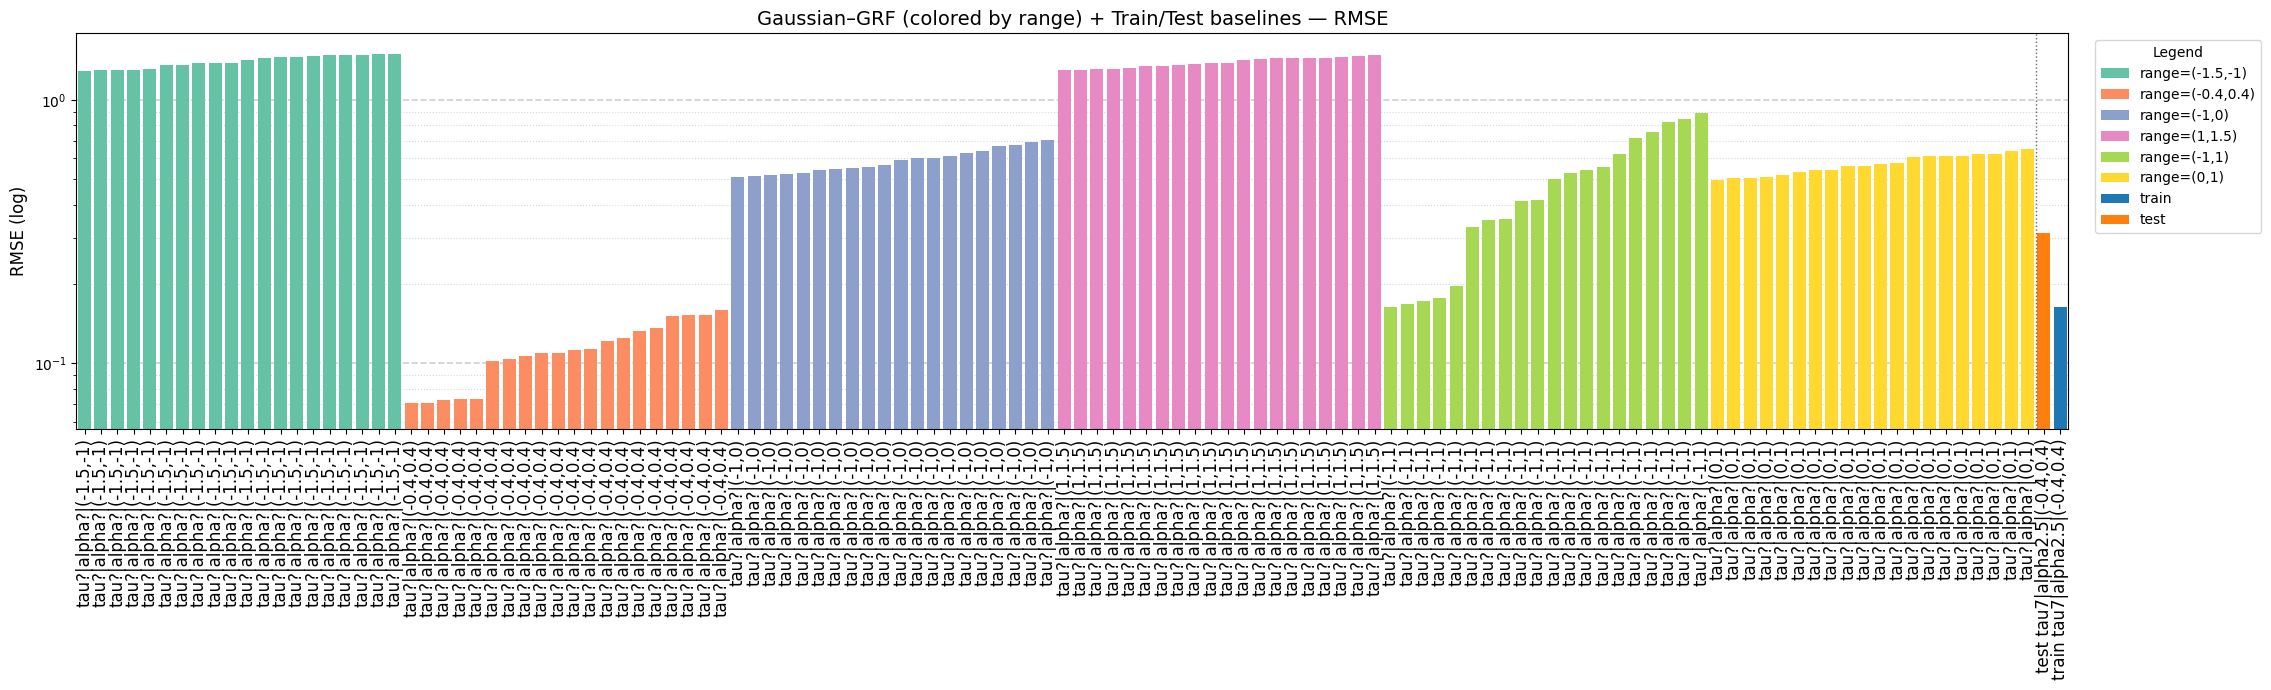

In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 只要不换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_alpha_tau(row):
    """优先用列值，否则从 dataset_name 兜底正则提取"""
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name", ""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

# ---------- 读 generalizability CSV -> 只保留 family=GRF & kernel=matern ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)

df_grf = df_grf[(df_grf["family"] == "GRF") & (df_grf["kernel"] == "gaussian")].copy()

# —— 每根柱子的“单行”标签（不再写 GRF/Matern，避免重复）——
def make_bar_label(row):
    a, t = get_alpha_tau(row)
    r    = row["range_label"].replace("range=", "")  # 简化显示
    return f"tau{t}|alpha{a}|{r}"

df_grf["bar_label"] = df_grf.apply(make_bar_label, axis=1)

# 颜色：range -> 色相
all_ranges = df_grf["range_label"].dropna().unique().tolist()
palette = plt.cm.Set2.colors if len(all_ranges) <= 8 else plt.cm.tab20.colors
range2color = {rg: palette[i % len(palette)] for i, rg in enumerate(all_ranges)}
def color_by_range(row):
    return range2color.get(row["range_label"], (0.7, 0.7, 0.7))

# 排序：可以按 range + rmse（或保持原顺序）——这里按 range 后 rmse
range_order = {rg:i for i,rg in enumerate(all_ranges)}
df_grf = (df_grf
          .assign(__sort=df_grf.apply(lambda r: (range_order.get(r["range_label"], 1e9),
                                                 float(r["rmse_mean"]) if pd.notna(r["rmse_mean"]) else np.inf), axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True))

# ---------- 读 train/test CSV -> 两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# 为 baseline 准备标签（单行）
def base_label(row):
    if row["split"] == "train":
        return TRAIN_DESC
    else:
        return TEST_DESC

df_base["bar_label"] = df_base.apply(base_label, axis=1)

# 合并：所有 Matern-GRF 在前，train/test 两根柱在最后
df_grf["__is_baseline"] = False
df_base["__is_baseline"] = True
df_all = pd.concat([df_grf, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图（单轴，所有柱都带标签） ----------
fig_w = max(24, int(len(df_all) * 0.095))  # 更宽一点以容纳所有单行标签
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# 颜色：GRF-一般化集按 range；baseline 两根固定颜色以突出
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}
colors = []
for _, r in df_all.iterrows():
    if r["__is_baseline"]:
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_range(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：GRF 段 与 baseline 段之间
baseline_start = len(df_grf)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("Gaussian–GRF (colored by range) + Train/Test baselines — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 每根柱都显示“单行”标签（不换行）
labels = df_all["bar_label"].tolist()
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=12)  # 旋转 90° 避免重叠

# 图例：range & baseline
legend_elements = []
for rg in all_ranges:
    legend_elements.append(Patch(facecolor=range2color[rg], edgecolor="none", label=rg))
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_matern_grf_with_train_test_all_labeled.png", dpi=200, bbox_inches="tight")

/tmp/ipykernel_311054/3969236800.py:144: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


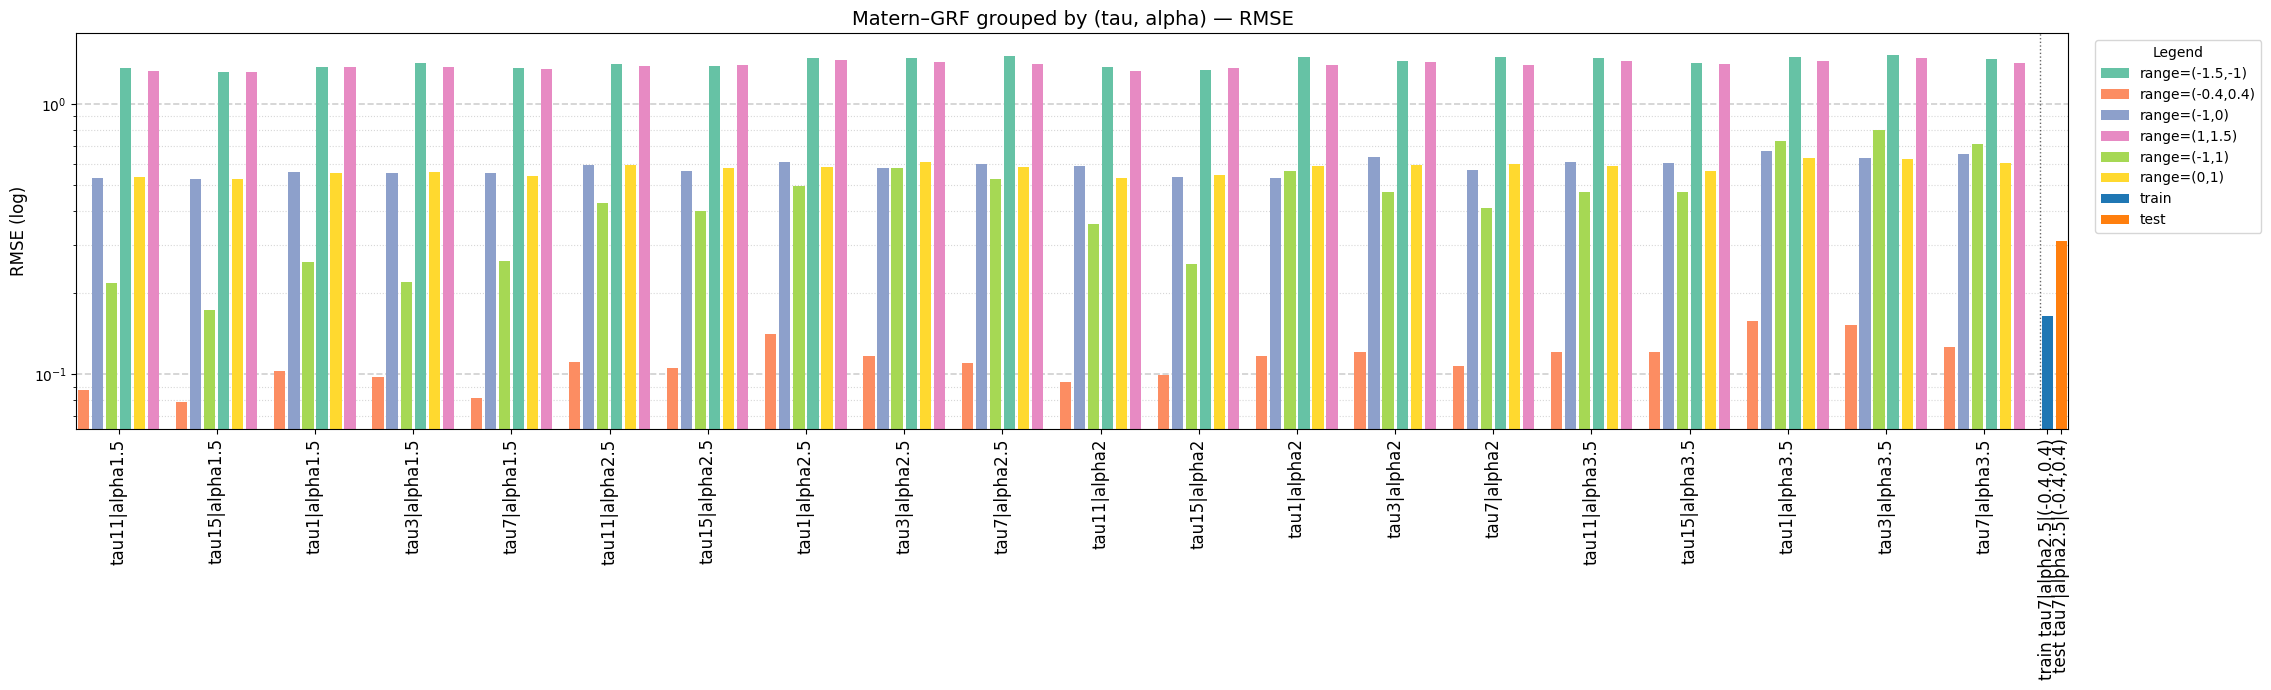

In [1]:
# -*- coding: utf-8 -*-
"""
Plot RMSE for Matern–GRF datasets grouped by (tau, alpha).

Changes relative to the original version
---------------------------------------
1. **Grouping & Ordering**
   • Bars are grouped by the tuple (tau, alpha).
   • Within each group the _innermost_ sort key is `range`, ensuring
     the six ranges appear in a consistent left-to-right order.
   • A fixed gap (``GAP=1``) is inserted _between_ groups so blocks of
     6 bars visually stand apart.
2. **X-tick Labelling**
   • We label the **group** once – centred underneath the 6 bars – using
     ``tau{T}|alpha{A}`` with **no range text**.
3. **Baseline Bars**
   • Train / test baselines are appended after all GRF groups and still
     carry their descriptive labels.
   • A dashed separator line marks the transition from GRF blocks to
     baselines.

USAGE
-----
Change `CSV_GRF`, `CSV_BASE`, `TRAIN_DESC`, `TEST_DESC` to match your
paths / descriptions, then run:

>>> python plot_rmse_grouped.py

The plot pops up (or you can uncomment the final ``plt.savefig`` line).
"""

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =======  EDIT THESE PATHS AS NEEDED  =======
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# (optional) one-line captions for the train / test baselines
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ------------------------------------------------------------
#  Helper functions
# ------------------------------------------------------------

def extract_family_kernel(row: pd.Series) -> pd.Series:
    """Return family & kernel from mixed-in text columns."""
    txt = "{} {}".format(row.get("type", ""), row.get("dataset_name", "")).lower()

    # --- family ---
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # --- kernel (multi-heuristic) ---
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic", "rationalquadratic",
            "se", "sqexp", "squared_exponential", "squaredexponential",
            "gauss", "exp_quadratic", "expquadratic",
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k: str | None) -> str:
        if not k:
            return "other"
        k = k.lower()
        if k in {
            "gauss", "gaussian", "rbf", "se", "sqexp", "squared_exponential",
            "squaredexponential", "exp_quadratic", "expquadratic",
        }:
            return "gaussian"
        if k in {"rq", "rational_quadratic", "rationalquadratic"}:
            return "rq"
        return k

    return pd.Series({"family": family, "kernel": canon(kernel_raw)})


def fmt_float(v) -> str:
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)


def build_range_label(row: pd.Series) -> str:
    """Return canonical range string, e.g. 'range=(-0.4,0.4)'."""
    lo, hi = row.get("vmin", np.nan), row.get("vmax", np.nan)
    if pd.isna(lo) or pd.isna(hi):
        return "range=unknown"
    lo, hi = float(lo), float(hi)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"


def get_alpha_tau(row: pd.Series) -> tuple[str, str]:
    """Return (alpha, tau) strings, pulling from columns or dataset_name."""
    alpha, tau = row.get("alpha", np.nan), row.get("tau", np.nan)
    name = str(row.get("dataset_name", ""))
    if pd.isna(alpha) or alpha == "":
        m = re.search(r"alpha([0-9eE\.-]+)", name)
        if m:
            alpha = m.group(1)
    if pd.isna(tau) or tau == "":
        m = re.search(r"tau([0-9eE\.-]+)", name)
        if m:
            tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

# ------------------------------------------------------------
#  Load + wrangle GRF data (Matern only)
# ------------------------------------------------------------

df_grf = pd.read_csv(CSV_GRF)

# cast numerics where sensible
for col in df_grf.columns:
    if col in ("dataset_name", "dataset_path", "type", "solver"):
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

# add structural columns

df_grf[["family", "kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)

# keep only GRF-Matern rows
mask = (df_grf["family"] == "GRF") & (df_grf["kernel"] == "matern")
df_grf = df_grf.loc[mask].copy()

# alpha / tau helpers + grouping key  -------------------------

df_grf[["alpha_str", "tau_str"]] = df_grf.apply(
    lambda r: pd.Series(get_alpha_tau(r)), axis=1
)
df_grf["group_label"] = df_grf.apply(
    lambda r: f"tau{r['tau_str']}|alpha{r['alpha_str']}", axis=1
)

# colour palette ---------------------------------------------

all_ranges = df_grf["range_label"].dropna().unique().tolist()
palette = (
    plt.cm.Set2.colors if len(all_ranges) <= 8 else plt.cm.tab20.colors
)
range2color = {rg: palette[i % len(palette)] for i, rg in enumerate(all_ranges)}

def color_by_range(row: pd.Series):
    return range2color.get(row["range_label"], (0.7, 0.7, 0.7))

# build a stable inner sort for ranges
range_order = {rg: i for i, rg in enumerate(sorted(all_ranges))}

# ------------------------------------------------------------
#  Load baseline (train / test) CSV
# ------------------------------------------------------------

df_base = pd.read_csv(CSV_BASE)
for c in ("rmse_mean", "N"):
    df_base[c] = pd.to_numeric(df_base[c], errors="coerce")

def parse_split(name: str) -> str:
    name = str(name).lower()
    if re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if re.search(r"(?:^|_)test(?:_|$)", name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base.query("split in ['train','test']").copy()

# tidy baseline labels (single-line)
df_base["bar_label"] = df_base["split"].map({"train": TRAIN_DESC, "test": TEST_DESC})

# ------------------------------------------------------------
#  Build plotting records with explicit x-positions & gaps
# ------------------------------------------------------------

records: list[dict] = []
xticks:   list[float] = []
xticklabels: list[str] = []

GAP = 1        # extra x-units inserted between groups
x = 0.0

# --- iterate group by group ---
for g, gdf in df_grf.groupby("group_label", sort=False):
    gdf_sorted = gdf.sort_values(
        by="range_label",
        key=lambda col: [range_order[v] for v in col],
    )
    start_x = x
    for _idx, row in gdf_sorted.iterrows():
        d = row.to_dict()
        d["xpos"] = x
        d["color"] = color_by_range(row)
        d["label"] = None  # individual bar labels now hidden
        records.append(d)
        x += 1

    # centre tick once per group
    centre = (start_x + x - 1) / 2
    xticks.append(centre)
    xticklabels.append(g)

    x += GAP  # visual gap before next group

# save marker for baseline separator
baseline_x_start = x

# --- append baseline bars ---
BASE_COLORS = {"train": "#1f77b4", "test": "#ff7f0e"}
for _idx, row in df_base.iterrows():
    d = row.to_dict()
    d["xpos"] = x
    d["color"] = BASE_COLORS.get(row["split"], "#999999")
    d["label"] = row["bar_label"]
    records.append(d)

    xticks.append(x)
    xticklabels.append(row["bar_label"])

    x += 1

# ------------------------------------------------------------
#  DataFrame ready for plotting
# ------------------------------------------------------------

plot_df = pd.DataFrame.from_records(records)

# y-axis bounds (log) ----------------------------------------
rmse_vals = pd.to_numeric(plot_df["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[rmse_vals > 0].dropna()
ymin = (rmse_vals.min() * 0.8) if not rmse_vals.empty else 1e-3
ymax = (rmse_vals.max() * 1.2) if not rmse_vals.empty else 1.0

# ------------------------------------------------------------
#  P L O T
# ------------------------------------------------------------

fig_w = max(24, int(len(plot_df) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

ax.bar(
    plot_df["xpos"],
    plot_df["rmse_mean"].astype(float),
    color=plot_df["color"],
    edgecolor="none",
)

# separator before baselines
ax.axvline(baseline_x_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# grid & axes
ax.set_axisbelow(True)
ax.grid(axis="y", which="major", linestyle="--", linewidth=1.2, alpha=0.6)
ax.grid(axis="y", which="minor", linestyle=":",  linewidth=0.8, alpha=0.5)
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(-0.5, plot_df["xpos"].max() + 0.5)
ax.set_title("Matern–GRF grouped by (tau, alpha) — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# ticks (once per group or baseline entry)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)

# legend (ranges + baselines)
legend_elems = [
    Patch(facecolor=range2color[r], edgecolor="none", label=r)
    for r in all_ranges
]
legend_elems.append(Patch(facecolor=BASE_COLORS["train"], edgecolor="none", label="train"))
legend_elems.append(Patch(facecolor=BASE_COLORS["test"],  edgecolor="none", label="test"))
ax.legend(
    handles=legend_elems,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    title="Legend",
)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# to save instead of / in addition to showing:
# plt.savefig("rmse_matern_grf_grouped.png", dpi=200, bbox_inches="tight")


/tmp/ipykernel_934028/976343446.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")


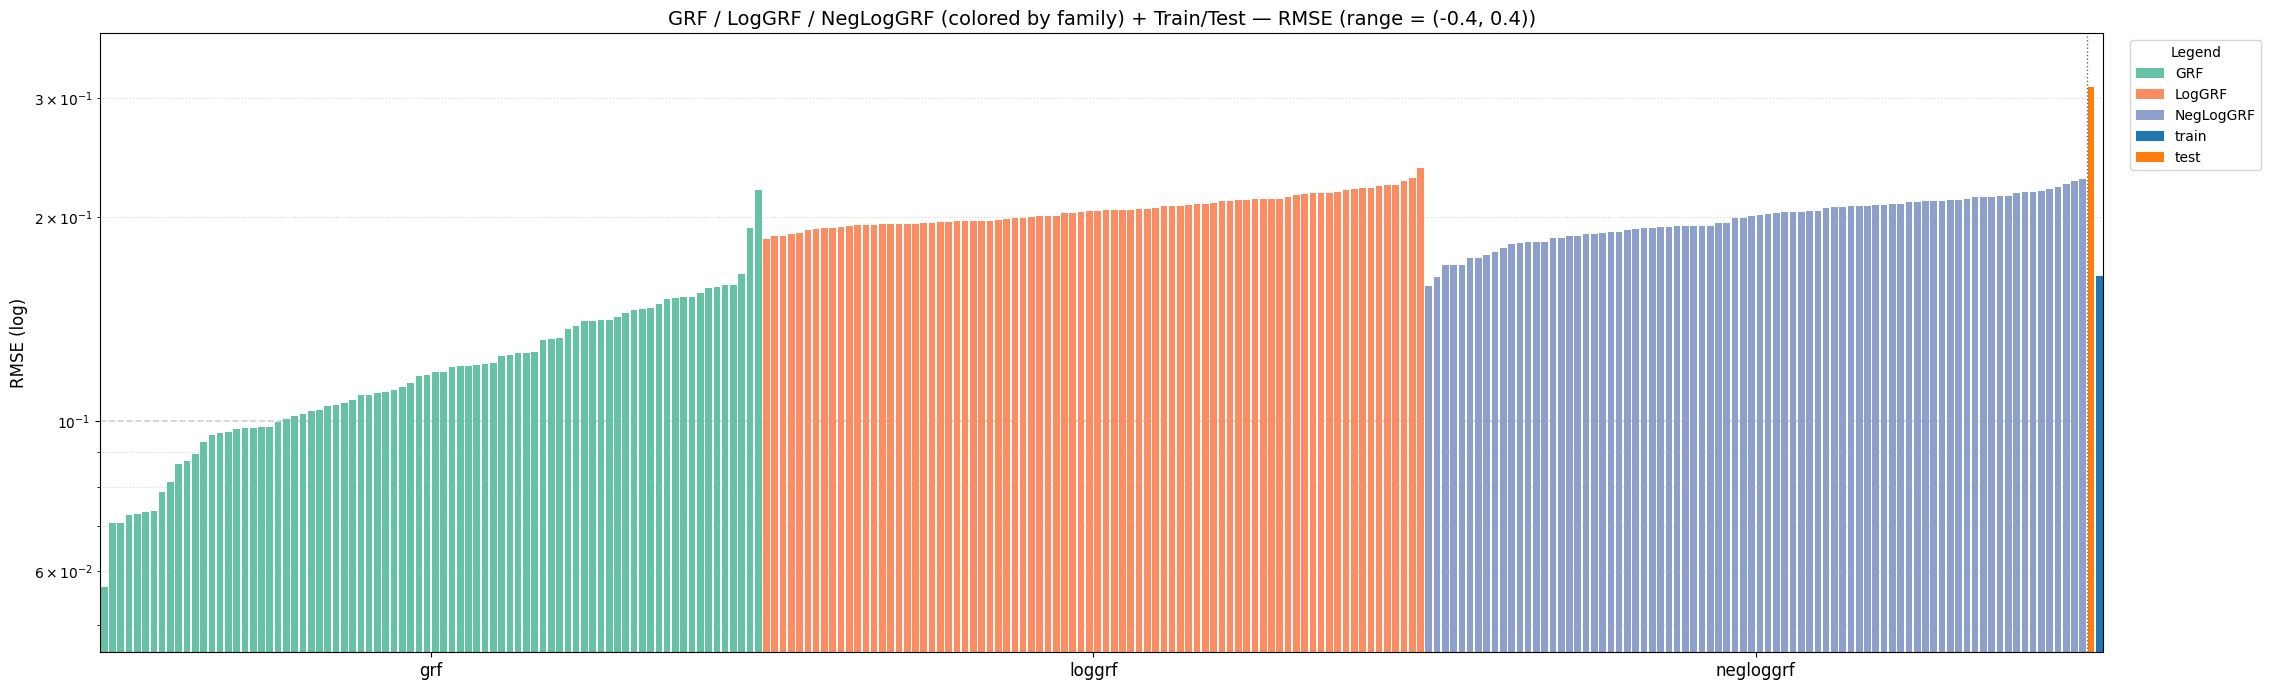

In [6]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 只要不换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_alpha_tau(row):
    """优先用列值，否则从 dataset_name 兜底正则提取"""
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name", ""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

# ---------- 读 generalizability CSV -> 保留 family in {GRF, LogGRF, NegLogGRF} 且 range=(-0.4,0.4) ----------
df_gen = pd.read_csv(CSV_GRF)
for col in df_gen.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")

df_gen[["family","kernel"]] = df_gen.apply(extract_family_kernel, axis=1)
df_gen["range_label"] = df_gen.apply(build_range_label, axis=1)

# 只保留三类 family
df_gen = df_gen[df_gen["family"].isin(["GRF","LogGRF","NegLogGRF"])].copy()

# 只保留 range == (-0.4,0.4)（容差判断）
def in_target_range(row, target=(-0.4, 0.4), tol=1e-9):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return False
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return (abs(lo - target[0]) <= tol) and (abs(hi - target[1]) <= tol)

df_gen = df_gen[df_gen.apply(in_target_range, axis=1)].copy()

# —— 每根柱子的“单行”标签（不写 family，避免重复；保留 tau/alpha/range）——
def make_bar_label(row):
    a, t = get_alpha_tau(row)
    r    = row["range_label"].replace("range=", "")  # 简化显示
    return f"tau{t}|alpha{a}|{r}"

df_gen["bar_label"] = df_gen.apply(make_bar_label, axis=1)

# 颜色：按 family
family_order = ["GRF", "LogGRF", "NegLogGRF"]
palette = plt.cm.Set2.colors if len(family_order) <= 8 else plt.cm.tab20.colors
family2color = {fam: palette[i % len(palette)] for i, fam in enumerate(family_order)}

def color_by_family(row):
    return family2color.get(row["family"], (0.7, 0.7, 0.7))

# 排序：family -> rmse（升序）
fam_order = {f:i for i,f in enumerate(family_order)}
df_gen = (
    df_gen.assign(
        __sort=df_gen.apply(
            lambda r: (fam_order.get(r["family"], 1e9),
                       float(r["rmse_mean"]) if pd.notna(r["rmse_mean"]) else np.inf),
            axis=1)
    )
    .sort_values(by="__sort", kind="mergesort")
    .drop(columns="__sort")
    .reset_index(drop=True)
)

# ---------- 读 train/test CSV -> 两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# baseline 标签
def base_label(row):
    return TRAIN_DESC if row["split"] == "train" else TEST_DESC

df_base["bar_label"] = df_base.apply(base_label, axis=1)

# 合并：generalizability 在前，train/test 两根柱在最后
df_gen["__is_baseline"] = False
df_base["__is_baseline"] = True
df_all = pd.concat([df_gen, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图（单轴，所有柱都带标签） ----------
fig_w = max(24, int(len(df_all) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# 颜色：generalizability 按 family；baseline 固定颜色
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}
colors = []
for _, r in df_all.iterrows():
    if r["__is_baseline"]:
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_family(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：GRF 段 与 baseline 段之间
baseline_start = len(df_gen)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("GRF / LogGRF / NegLogGRF (colored by family) + Train/Test — RMSE (range = (-0.4, 0.4))", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 每根柱都显示“单行”标签（不换行）
present_families = [f for f in ["GRF", "LogGRF", "NegLogGRF"] if f in set(df_gen["family"])]
centers, xticklabels = [], []
for fam in present_families:
    pos = np.where((~df_all["__is_baseline"]) & (df_all["family"] == fam))[0]
    if len(pos):
        centers.append(pos.mean())          # 该 family 这一段的中心
        xticklabels.append(fam.lower())     # 用小写：grf / loggrf / negloggrf

ax.set_xticks(centers)
ax.set_xticklabels(xticklabels, fontsize=12)

# 图例：family & baseline
legend_elements = [Patch(facecolor=family2color[f], edgecolor="none", label=f) for f in family_order]
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_family_range-0.4_0.4.png", dpi=200, bbox_inches="tight")


/tmp/ipykernel_934028/3936715047.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")


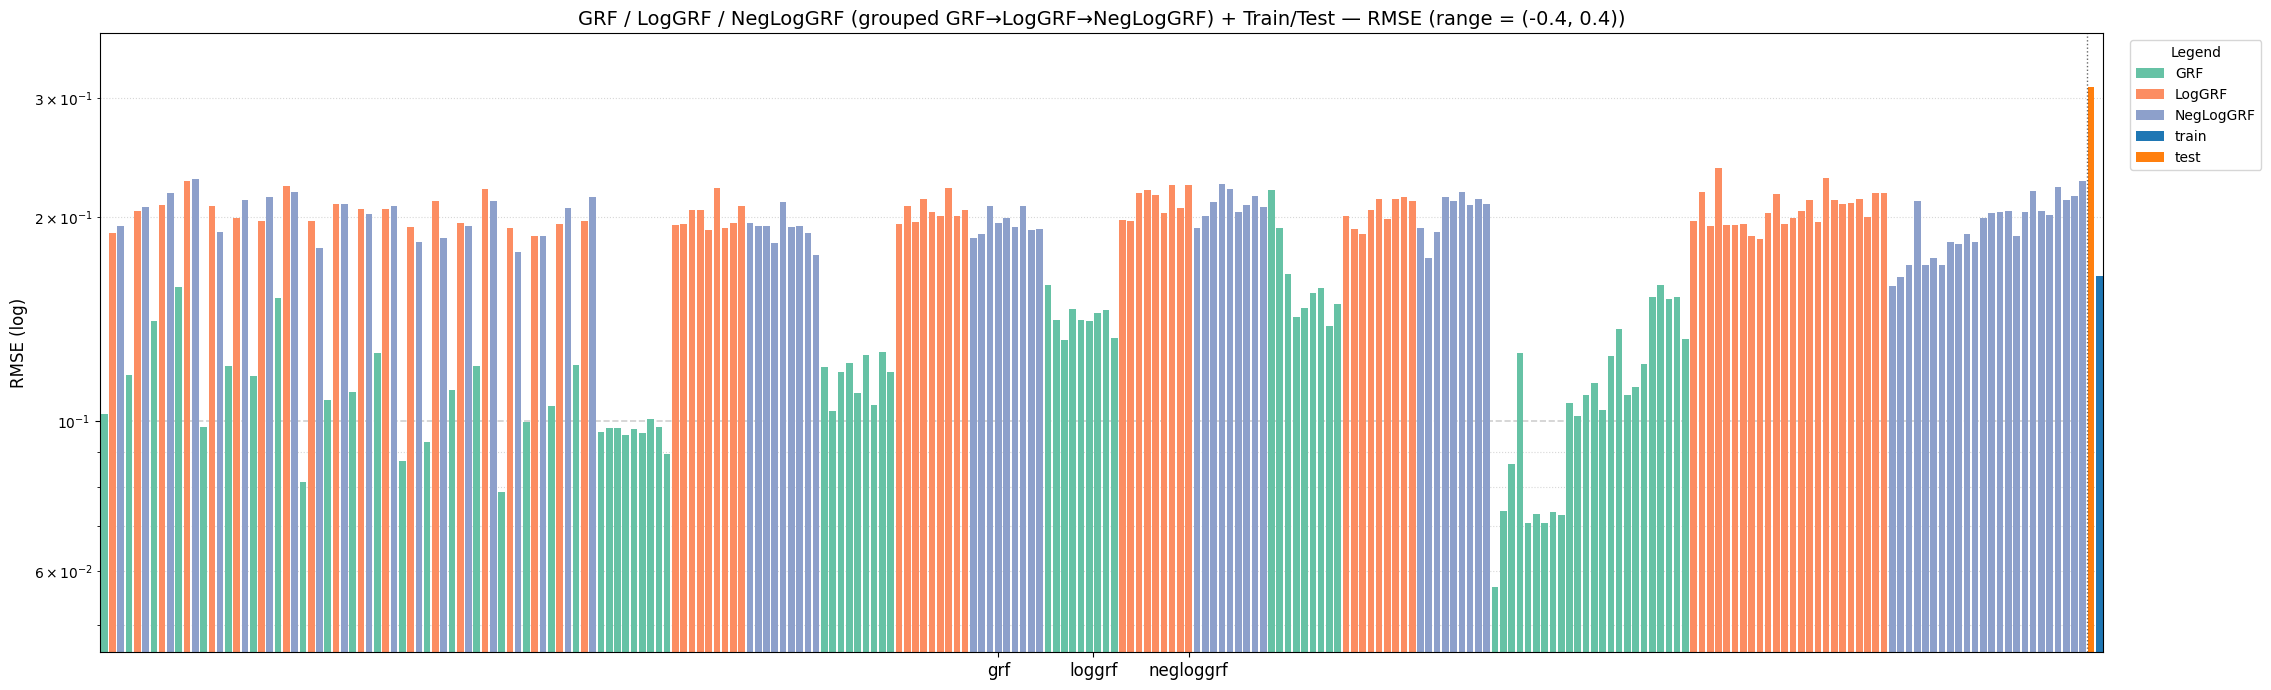

In [7]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 只要不换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_alpha_tau(row):
    """优先用列值，否则从 dataset_name 兜底正则提取"""
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name", ""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

# ---------- 读 generalizability CSV -> 保留 family in {GRF, LogGRF, NegLogGRF} 且 range=(-0.4,0.4) ----------
df_gen = pd.read_csv(CSV_GRF)
for col in df_gen.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")

df_gen[["family","kernel"]] = df_gen.apply(extract_family_kernel, axis=1)
df_gen["range_label"] = df_gen.apply(build_range_label, axis=1)

# 只保留三类 family
df_gen = df_gen[df_gen["family"].isin(["GRF","LogGRF","NegLogGRF"])].copy()

# 只保留 range == (-0.4,0.4)（容差判断）
def in_target_range(row, target=(-0.4, 0.4), tol=1e-9):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return False
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return (abs(lo - target[0]) <= tol) and (abs(hi - target[1]) <= tol)

df_gen = df_gen[df_gen.apply(in_target_range, axis=1)].copy()

# —— 每根柱子的“单行”标签（不写 family，避免重复；保留 tau/alpha/range）——
def make_bar_label(row):
    a, t = get_alpha_tau(row)
    r    = row["range_label"].replace("range=", "")  # 简化显示
    return f"tau{t}|alpha{a}|{r}"

df_gen["bar_label"] = df_gen.apply(make_bar_label, axis=1)

# —— 为排序准备分组键：tau/alpha（字符串 + 数值）
alpha_tau = df_gen.apply(get_alpha_tau, axis=1)
df_gen["alpha_s"] = [a for a, t in alpha_tau]
df_gen["tau_s"]   = [t for a, t in alpha_tau]
df_gen["alpha_f"] = pd.to_numeric(df_gen["alpha_s"], errors="coerce")
df_gen["tau_f"]   = pd.to_numeric(df_gen["tau_s"],   errors="coerce")

# 颜色：按 family
family_order = ["GRF", "LogGRF", "NegLogGRF"]
palette = plt.cm.Set2.colors if len(family_order) <= 8 else plt.cm.tab20.colors
family2color = {fam: palette[i % len(palette)] for i, fam in enumerate(family_order)}

def color_by_family(row):
    return family2color.get(row["family"], (0.7, 0.7, 0.7))

# 排序：先按 tau，再按 alpha，最后在同一组内按 family（GRF→LogGRF→NegLogGRF）
fam_order = {f:i for i,f in enumerate(family_order)}  # GRF=0, LogGRF=1, NegLogGRF=2
df_gen = (
    df_gen.assign(
        __sort=df_gen.apply(
            lambda r: (
                r["tau_f"]   if pd.notna(r["tau_f"])   else np.inf,
                r["alpha_f"] if pd.notna(r["alpha_f"]) else np.inf,
                fam_order.get(r["family"], 1e9)
            ),
            axis=1)
    )
    .sort_values(by="__sort", kind="mergesort")
    .drop(columns="__sort")
    .reset_index(drop=True)
)

# ---------- 读 train/test CSV -> 两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# baseline 标签
def base_label(row):
    return TRAIN_DESC if row["split"] == "train" else TEST_DESC

df_base["bar_label"] = df_base.apply(base_label, axis=1)

# 合并：generalizability 在前，train/test 两根柱在最后
df_gen["__is_baseline"] = False
df_base["__is_baseline"] = True
df_all = pd.concat([df_gen, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图 ----------
fig_w = max(24, int(len(df_all) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# 颜色：generalizability 按 family；baseline 固定颜色
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}
colors = []
for _, r in df_all.iterrows():
    if r["__is_baseline"]:
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_family(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：generalizability 段 与 baseline 段之间
baseline_start = len(df_gen)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("GRF / LogGRF / NegLogGRF (grouped GRF→LogGRF→NegLogGRF) + Train/Test — RMSE (range = (-0.4, 0.4))", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 稀疏 x 轴：只在整个 non-baseline 段上按 family 放 3 个刻度（取该 family 所有柱位置的均值作为刻度位置）
present_families = [f for f in family_order if f in set(df_gen["family"])]
centers, xticklabels = [], []
for fam in present_families:
    pos = np.where((~df_all["__is_baseline"]) & (df_all["family"] == fam))[0]
    if len(pos):
        centers.append(pos.mean())
        xticklabels.append(fam.lower())  # grf / loggrf / negloggrf

ax.set_xticks(centers)
ax.set_xticklabels(xticklabels, fontsize=12)

# 图例：family & baseline
legend_elements = [Patch(facecolor=family2color[f], edgecolor="none", label=f) for f in family_order]
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_family_range-0.4_0.4_grouped.png", dpi=200, bbox_inches="tight")


/tmp/ipykernel_934028/2842129869.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")


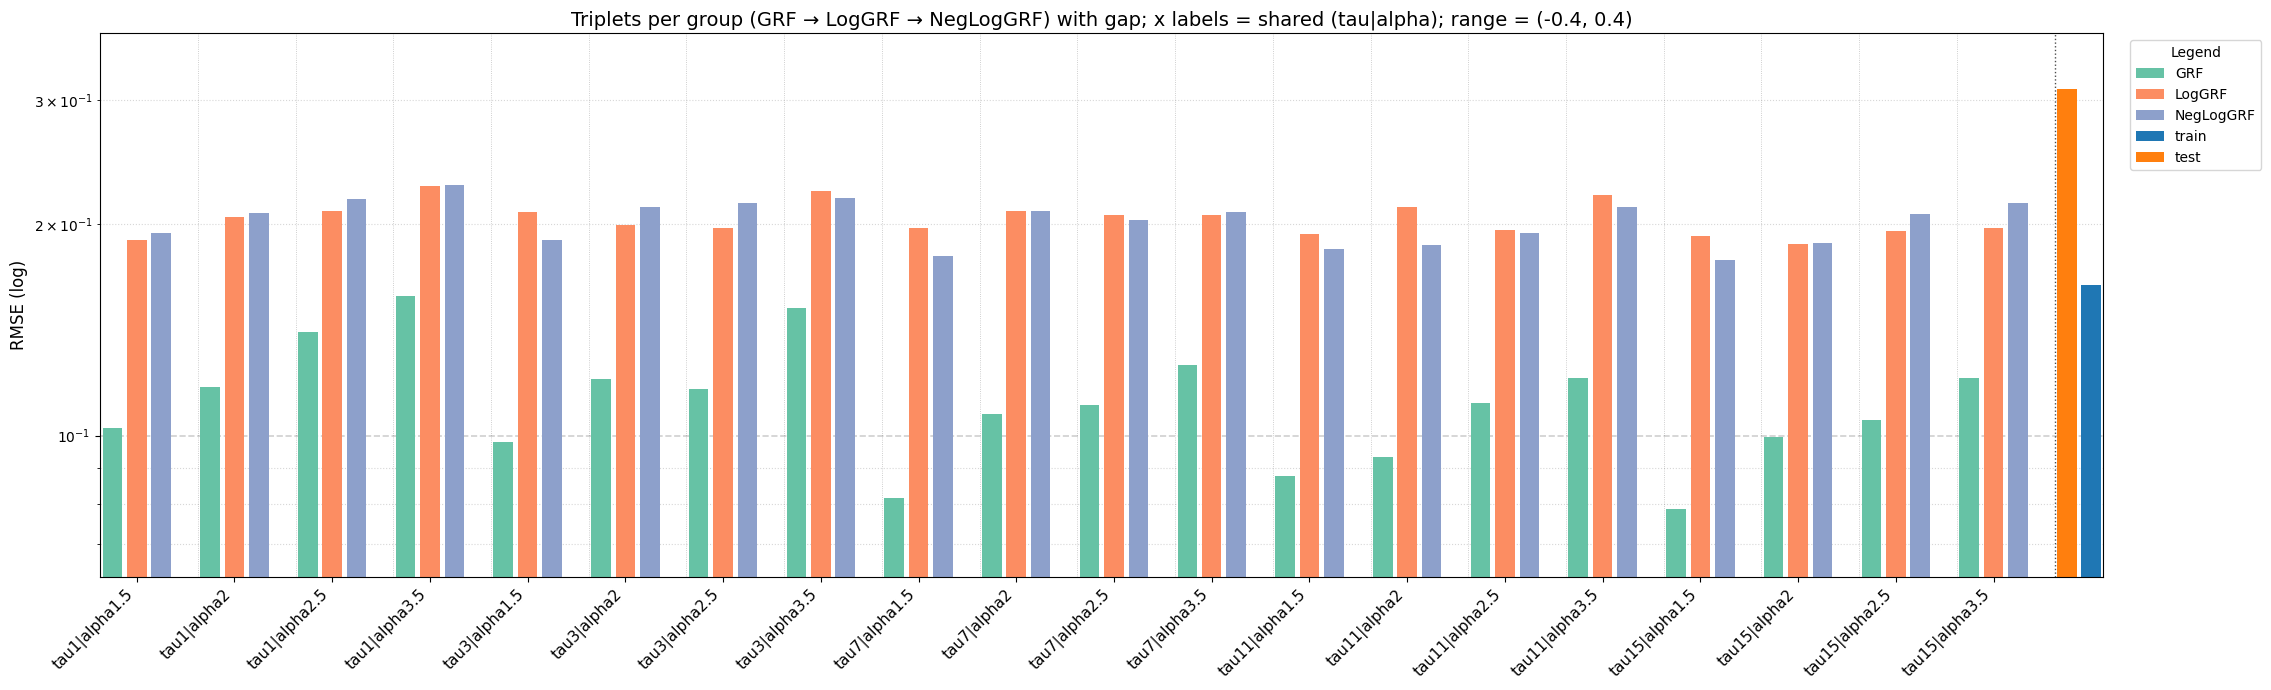

In [10]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析 ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m: kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m: kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in ["matern","periodic","gaussian","rbf","rq",
                   "rational_quadratic","rationalquadratic",
                   "se","sqexp","squared_exponential","squaredexponential",
                   "gauss","exp_quadratic","expquadratic"]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k: return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    return pd.Series({"family": family, "kernel": canon(kernel_raw)})

def fmt_float(v):
    try:
        return f"{float(v):.6g}"
    except Exception:
        return "?"

def get_alpha_tau(row):
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name",""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

def in_target_range(row, target=(-0.4,0.4), tol=1e-9):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return False
    lo, hi = float(vmin), float(vmax)
    if lo > hi: lo, hi = hi, lo
    return (abs(lo - target[0]) <= tol) and (abs(hi - target[1]) <= tol)

# ---------- 读 generalizability CSV & 过滤 ----------
df_gen = pd.read_csv(CSV_GRF)
for col in df_gen.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")

df_gen[["family","kernel"]] = df_gen.apply(extract_family_kernel, axis=1)
df_gen = df_gen[df_gen["family"].isin(["GRF","LogGRF","NegLogGRF"])].copy()
df_gen = df_gen[df_gen.apply(in_target_range, axis=1)].copy()

# 组键：tau/alpha（字符串+数值，便于排序与显示）
alpha_tau = df_gen.apply(get_alpha_tau, axis=1)
df_gen["alpha_s"] = [a for a, t in alpha_tau]
df_gen["tau_s"]   = [t for a, t in alpha_tau]
df_gen["alpha_f"] = pd.to_numeric(df_gen["alpha_s"], errors="coerce")
df_gen["tau_f"]   = pd.to_numeric(df_gen["tau_s"],   errors="coerce")

# 将同一 (tau, alpha, family) 的多行做汇总（均值）；如果你想保留每一行，把这里改掉即可
df_gen = (df_gen
          .groupby(["tau_s","alpha_s","tau_f","alpha_f","family"], as_index=False)
          .agg(rmse_mean=("rmse_mean","mean")))

# 分组顺序：按 tau -> alpha 升序
groups = (df_gen[["tau_s","alpha_s","tau_f","alpha_f"]]
          .drop_duplicates()
          .sort_values(by=["tau_f","alpha_f"], kind="mergesort")
          .reset_index(drop=True))

# family 顺序 & 颜色
family_order = ["GRF","LogGRF","NegLogGRF"]
palette = plt.cm.Set2.colors if len(family_order) <= 8 else plt.cm.tab20.colors
family2color = {fam: palette[i % len(palette)] for i, fam in enumerate(family_order)}
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}

# ---------- 读 train/test CSV ----------
df_base = pd.read_csv(CSV_BASE)
def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name): return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name): return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# ---------- 手工布局：三根一空，x 轴只在每组中心打共同信息 ----------
group_gap  = 1.0      # 每组三根后空一个槽
bar_width  = 0.8
x_pos, y_val, colors = [], [], []
group_centers, group_labels = [], []

for g_idx, g in groups.iterrows():
    start = g_idx * (3 + group_gap)          # 该组起始 x
    center = start + 1                        # 三根中的中间一根位置
    group_centers.append(center)
    group_labels.append(f"tau{g['tau_s']}|alpha{g['alpha_s']}")  # 组共同信息

    for i, fam in enumerate(family_order):
        sel = df_gen[(df_gen["tau_s"]==g["tau_s"]) &
                     (df_gen["alpha_s"]==g["alpha_s"]) &
                     (df_gen["family"]==fam)]
        if len(sel):  # 有该 family 的数据就画柱；没有则保留空槽（不画）
            x_pos.append(start + i)
            y_val.append(float(sel["rmse_mean"].iloc[0]))
            colors.append(family2color[fam])

# baseline 放最后，与前面组之间留一条竖线，不加 x 轴标签
baseline_start = len(groups) * (3 + group_gap)
for j, (_, row) in enumerate(df_base.iterrows()):
    x_pos.append(baseline_start + j)
    y_val.append(float(row["rmse_mean"]))
    colors.append(base_color_map.get(row["split"], "#999999"))

# ---------- y 轴范围（log） ----------
rmse_vals = pd.Series(y_val)
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图 ----------
total_slots = len(groups) * (3 + group_gap) + len(df_base)
fig_w = max(24, int(total_slots * 0.08))
fig, ax = plt.subplots(figsize=(fig_w, 7))

ax.bar(x_pos, y_val, width=bar_width, color=colors, edgecolor="none")

# 分隔线：generalizability 段 与 baseline 段之间
if len(df_base) > 0:
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.7)

# 组分隔线（淡）
for g_idx in range(1, len(groups)):
    edge_x = g_idx * (3 + group_gap) - 0.5
    ax.axvline(edge_x, color="black", lw=0.6, ls=":", alpha=0.25)

# 网格 & 轴
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
xmax = (baseline_start + len(df_base) - 1) if len(df_base) else (len(groups) * (3 + group_gap) - 1)
ax.set_xlim(-0.5, xmax + 0.5)

ax.set_title("Triplets per group (GRF → LogGRF → NegLogGRF) with gap; x labels = shared (tau|alpha); range = (-0.4, 0.4)", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# ✅ x 轴：只在每组中心打“共同信息”标签（不再写 grf/loggrf/negloggrf）
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, fontsize=11, rotation=45, ha="right")

# 图例：family & baseline
legend_elements = [Patch(facecolor=family2color[f], edgecolor="none", label=f) for f in family_order]
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_triplets_group_labels.png", dpi=200, bbox_inches="tight")


/tmp/ipykernel_934028/4182323808.py:152: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")


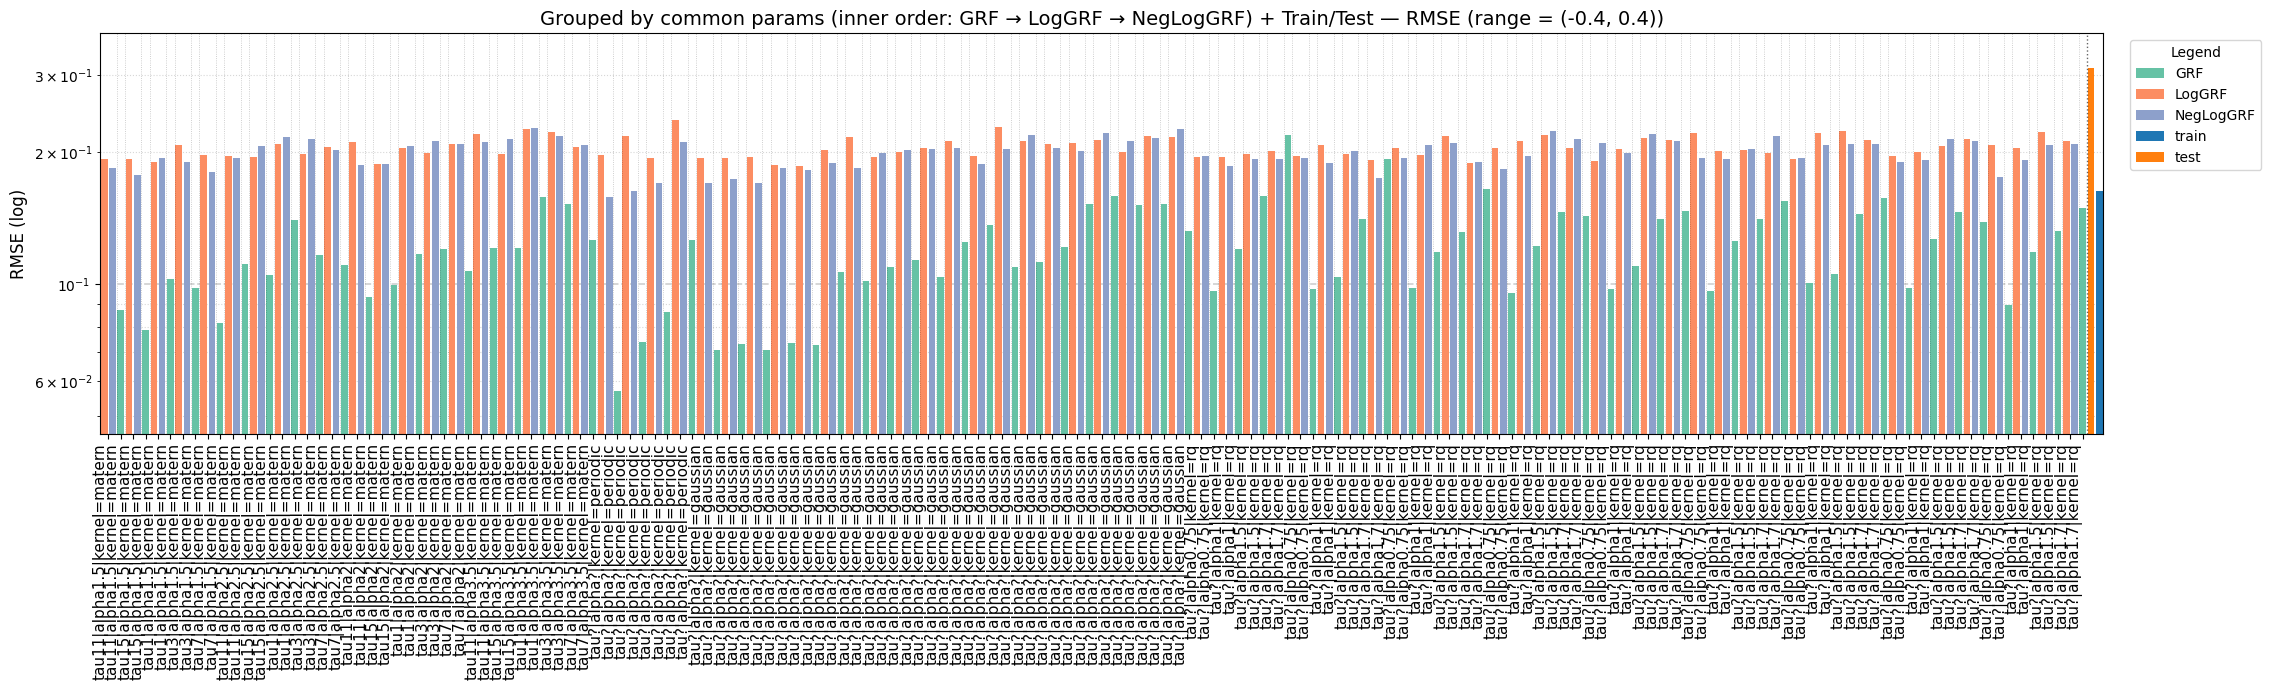

In [12]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 只要不换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 解析 ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def get_alpha_tau(row):
    """优先用列值，否则从 dataset_name 兜底正则提取"""
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name", ""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def in_target_range(row, target=(-0.4, 0.4), tol=1e-9):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return False
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return (abs(lo - target[0]) <= tol) and (abs(hi - target[1]) <= tol)

# 额外：解析 correlation length（cl），bc
def parse_cl(name_text: str):
    name = str(name_text).lower()
    m = re.search(r"(?:correlation_length\s*=\s*|cl)([0-9eE\.\-]+)", name)
    return fmt_float(m.group(1)) if m else "?"

def parse_bc(name_text: str):
    name = str(name_text).lower()
    m = re.search(r"bc\s*=?\s*([a-z]+)", name)
    return m.group(1) if m else "?"

# 为“组标签”（共同信息）构造友好字符串
def make_group_label(row):
    a, t = get_alpha_tau(row)
    cl = parse_cl(row.get("dataset_name", ""))
    ker = row.get("kernel", "other")
    bc = parse_bc(row.get("dataset_name",""))
    # range 恒定 (-0.4,0.4)，这里不再重复
    parts = [f"tau{t}", f"alpha{a}"]
    if ker and ker != "other":
        parts.append(f"kernel={ker}")
    if cl != "?":
        parts.append(f"cl={cl}")
    if bc != "?":
        parts.append(f"bc={bc}")
    return "|".join(parts)

# “family-less” 组键：把 family 词从文本里移除，用于排序/分组（不丢样本）
def familyless_key(row):
    txt = (str(row.get("dataset_name","")) + " " + str(row.get("type",""))).lower()
    # 去掉 family 标记
    txt = re.sub(r"(negloggrf|loggrf|grf)", "", txt)
    # 清理多余分隔符与空白
    txt = re.sub(r"[_\-]+", "_", txt)
    txt = re.sub(r"\s+", " ", txt).strip(" _-")
    return txt

# ---------- 读 generalizability CSV ----------
df_gen = pd.read_csv(CSV_GRF)
for col in df_gen.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")

df_gen[["family","kernel"]] = df_gen.apply(extract_family_kernel, axis=1)
df_gen["range_label"] = df_gen.apply(build_range_label, axis=1)

# 只保留三类 family + 指定区间
df_gen = df_gen[df_gen["family"].isin(["GRF","LogGRF","NegLogGRF"])].copy()
df_gen = df_gen[df_gen.apply(in_target_range, axis=1)].copy()

# 分组辅助列
alpha_tau = df_gen.apply(get_alpha_tau, axis=1)
df_gen["alpha_s"] = [a for a, t in alpha_tau]
df_gen["tau_s"]   = [t for a, t in alpha_tau]
df_gen["alpha_f"] = pd.to_numeric(df_gen["alpha_s"], errors="coerce")
df_gen["tau_f"]   = pd.to_numeric(df_gen["tau_s"],   errors="coerce")

# family-less 组键 + 组标签
df_gen["__group_key"]   = df_gen.apply(familyless_key, axis=1)
df_gen["__group_label"] = df_gen.apply(make_group_label, axis=1)

# ---------- 排序规则 ----------
# 外层：按“除 family 外的共同参数”排序（__group_key 的字典序基本就是 dataset_name 去掉 family 后的顺序）
# 内层：同一个组里按 family 固定顺序 GRF -> LogGRF -> NegLogGRF
family_order = ["GRF", "LogGRF", "NegLogGRF"]
fam_order = {f:i for i,f in enumerate(family_order)}

df_gen = (
    df_gen.assign(
        __fam=fam_order.get("GRF",0)  # 占位
    )
)
df_gen["__fam"] = df_gen["family"].map(fam_order)

df_gen = (df_gen
          .sort_values(by=["__group_key","__fam"], kind="mergesort")
          .reset_index(drop=True))

# ---------- baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# ---------- 合并用于画图（不改变顺序，只用于拿 y/颜色；x 我们单独计算组中心） ----------
df_gen["__is_baseline"] = False
df_base["__is_baseline"] = True
df_all = pd.concat([df_gen, df_base], ignore_index=True)

# ---------- y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 颜色 ----------
palette = plt.cm.Set2.colors if len(family_order) <= 8 else plt.cm.tab20.colors
family2color = {fam: palette[i % len(palette)] for i, fam in enumerate(family_order)}
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}

# ---------- 计算 x 位置：连续摆放（不聚合），每组中心打一个标签 ----------
# 先记下 generalizability 段的索引（0..len(df_gen)-1）
gen_n = len(df_gen)
x = np.arange(len(df_all))  # 0..len(gen)-1 为 gen，后面是 baseline

# 每个组的中心：取该组所有柱的 x 平均（通常每组三柱，中心就是中间那根）
centers, labels = [], []
for gkey, sub in df_gen.groupby("__group_key", sort=False):
    idx = sub.index.values  # 在 df_gen 中的行号
    centers.append(idx.mean())
    labels.append(sub["__group_label"].iloc[0])

# ---------- 画图 ----------
fig_w = max(24, int(len(df_all) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

# 颜色
colors = []
for _, r in df_all.iterrows():
    if r.get("__is_baseline", False):
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(family2color.get(r["family"], (0.7,0.7,0.7)))

y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)
bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：generalizability 段 与 baseline 段之间
baseline_start = gen_n
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 可选：组分隔线（淡）
# 找到每组的右边界：该组最后一个索引
group_right_edges = []
last_right = None
for gkey, sub in df_gen.groupby("__group_key", sort=False):
    right = sub.index.values.max()
    if last_right is not None and right > last_right:
        group_right_edges.append(last_right + 0.5)
    last_right = right
for edge in group_right_edges:
    ax.axvline(edge, color="black", lw=0.6, ls=":", alpha=0.25)

# 网格 & 轴
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("Grouped by common params (inner order: GRF → LogGRF → NegLogGRF) + Train/Test — RMSE (range = (-0.4, 0.4))", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# ✅ x 轴：只在每组中心打“共同信息”标签（不再写 grf/loggrf/negloggrf）
ax.set_xticks(centers)
ax.set_xticklabels(labels, fontsize=11, rotation=90, ha="right")

# 图例：family & baseline
legend_elements = [Patch(facecolor=family2color[f], edgecolor="none", label=f) for f in family_order]
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_grouped_family_innermost.png", dpi=220, bbox_inches="tight")


/tmp/ipykernel_934028/3799019049.py:162: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")


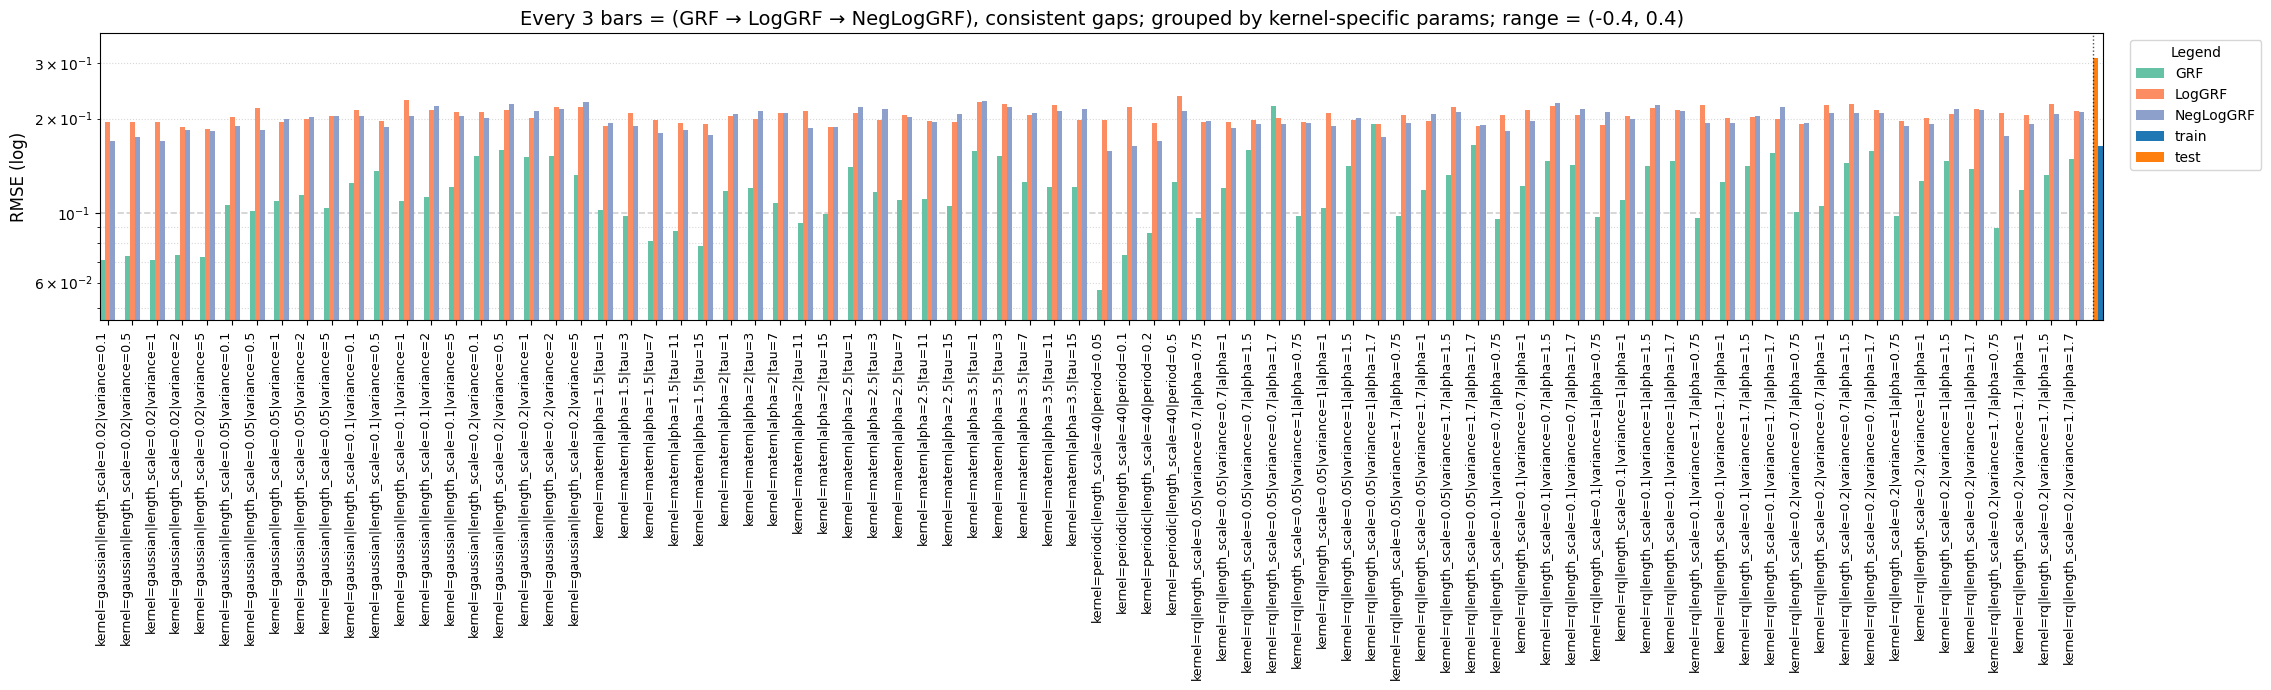

In [18]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）baseline 简短描述
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------------- 解析与工具函数 ----------------
def fmt_float(v):
    try:
        return f"{float(v):.6g}"
    except Exception:
        return "?"

def _get_text(row, keys=("type","dataset_name")):
    out = []
    for k in keys:
        v = row.get(k, None)
        if isinstance(v, str):
            out.append(v)
    return " ".join(out).lower()

def extract_family_kernel(row):
    txt = _get_text(row)
    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"
    # kernel（规范化：gaussian/rbf 视为 gaussian；rq 归一；其它保留）
    k = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m: k = m.group(1)
    if not k:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9_]+)", txt)
        if m: k = m.group(1)
    if not k:
        for kw in ["matern","periodic","gaussian","rbf","rq",
                   "rational_quadratic","rationalquadratic","se","sqexp"]:
            if kw in txt:
                k = kw
                break
    def canon_kernel(x):
        if not x: return "other"
        x = x.lower()
        if x in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if x in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return x
    kernel = canon_kernel(k)
    return pd.Series({"family": family, "kernel": kernel})

def get_alpha_tau(row):
    alpha = row.get("alpha", np.nan)
    tau   = row.get("tau",   np.nan)
    name  = str(row.get("dataset_name",""))
    if (pd.isna(alpha) or alpha == ""):
        m = re.search(r"alpha([0-9eE\.\-]+)", name)
        if m: alpha = m.group(1)
    if (pd.isna(tau) or tau == ""):
        m = re.search(r"tau([0-9eE\.\-]+)", name)
        if m: tau = m.group(1)
    return fmt_float(alpha), fmt_float(tau)

def in_target_range(row, target=(-0.4,0.4), tol=1e-9):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return False
    lo, hi = float(vmin), float(vmax)
    if lo > hi: lo, hi = hi, lo
    return (abs(lo - target[0]) <= tol) and (abs(hi - target[1]) <= tol)

# ---- 提取 kernel 专属参数 ----
def parse_number_from_name(name_text: str, keys):
    """在 dataset_name/type 中按若干 key 查找数值；keys 是可能的同义词列表"""
    txt = str(name_text).lower()
    for key in keys:
        # 支持 "key=1.23" 或 "key1.23"
        m = re.search(rf"{re.escape(key)}\s*=\s*([-+0-9.eE]+)", txt)
        if not m:
            m = re.search(rf"{re.escape(key)}\s*([-+0-9.eE]+)", txt)
        if m:
            try:
                return float(m.group(1))
            except:
                continue
    return np.nan

def kernel_params(row):
    """返回(ordered_fields, ordered_values)，按 kernel 选择字段并从 name/cols 中解析"""
    kernel = row["kernel"]
    name   = row.get("dataset_name","")
    # 字段映射表（你给的规则）
    if kernel == "periodic":
        fields = ["length_scale", "period"]
        ls = parse_number_from_name(name, ["length_scale","ls","ell","l","correlation_length","cl"])
        period = parse_number_from_name(name, ["period","per","T"])
        vals = [ls, period]
    elif kernel == "matern":
        fields = ["alpha", "tau"]
        a, t   = get_alpha_tau(row)
        try: a_f = float(a); 
        except: a_f = np.nan
        try: t_f = float(t); 
        except: t_f = np.nan
        vals = [a_f, t_f]
    elif kernel == "gaussian":
        fields = ["length_scale", "variance"]
        ls = parse_number_from_name(name, ["length_scale","ls","ell","l","correlation_length","cl"])
        var = parse_number_from_name(name, ["variance","var","sigma2","sigma_sq","amp2","amplitude2"])
        vals = [ls, var]
    elif kernel == "rq":
        fields = ["length_scale", "variance", "alpha"]
        ls = parse_number_from_name(name, ["length_scale","ls","ell","l","correlation_length","cl"])
        var = parse_number_from_name(name, ["variance","var","sigma2","sigma_sq","amp2","amplitude2"])
        a   = parse_number_from_name(name, ["alpha"])
        vals = [ls, var, a]
    else:
        fields = []
        vals   = []
    return fields, vals

def parse_bc(name_text: str):
    name = str(name_text).lower()
    m = re.search(r"bc\s*=?\s*([a-z]+)", name)
    return m.group(1) if m else "?"

def make_group_label(row):
    """组标签：kernel + 各自参数（不含 family）"""
    kernel = row["kernel"]
    fields, vals = kernel_params(row)
    items = [f"kernel={kernel}"]
    for k, v in zip(fields, vals):
        if not (v is None or (isinstance(v,float) and np.isnan(v))):
            items.append(f"{k}={fmt_float(v)}")
    # 可选：把 bc 也带上
    bc  = parse_bc(row.get("dataset_name",""))
    if bc != "?":
        items.append(f"bc={bc}")
    return "|".join(items) if items else kernel

# ---------------- 读 & 过滤 ----------------
df_gen = pd.read_csv(CSV_GRF)
for col in df_gen.columns:
    if col in ["dataset_name","dataset_path","type","solver"]:
        continue
    df_gen[col] = pd.to_numeric(df_gen[col], errors="ignore")

df_gen[["family","kernel"]] = df_gen.apply(extract_family_kernel, axis=1)
# 只保留 GRF/LogGRF/NegLogGRF & range=(-0.4,0.4)
df_gen = df_gen[df_gen["family"].isin(["GRF","LogGRF","NegLogGRF"])].copy()
df_gen = df_gen[df_gen.apply(in_target_range, axis=1)].copy()

# 组键（不含 family）：按 kernel 专属参数来
# 还可以把 bc 纳入组键，避免不同 bc 混在一起
group_keys = []
group_labels = []
for _, r in df_gen.iterrows():
    fields, vals = kernel_params(r)
    bc = parse_bc(r.get("dataset_name",""))
    # 组键 = (kernel, bc, 参数值…)，NaN 用 +inf 排到后面
    vals_norm = [ (v if (isinstance(v,float) and not np.isnan(v)) else np.inf) for v in vals ]
    gkey = (r["kernel"], bc, *vals_norm)
    group_keys.append(gkey)
    # 标签
    group_labels.append(make_group_label(r))
df_gen["__group_key"]   = group_keys
df_gen["__group_label"] = group_labels

# 排序：外层按组键，内层按 family 顺序（GRF→LogGRF→NegLogGRF），保持稳定
family_order = ["GRF","LogGRF","NegLogGRF"]
fam_order = {f:i for i,f in enumerate(family_order)}
df_gen["__fam"] = df_gen["family"].map(fam_order)
df_gen = df_gen.sort_values(by=["__group_key","__fam"], kind="mergesort").reset_index(drop=True)

# ---------------- baseline ----------------
df_base = pd.read_csv(CSV_BASE)
def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name): return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name): return "test"
    return "other"
df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# ---------------- 手工布局：严格“三根一组 + 组间留空” ----------------
# 思路：
#   1) 对于每个 __group_key，按 family_order 分桶；可能某family有多条 => 形成多“次”三根；
#   2) 每“三根”后插入固定的内间隔（inner_gap_slots）；每个组结束后插入外间隔（group_gap_slots）。
inner_gap_slots = 1    # 每组三根后留 1 个空槽
group_gap_slots = 1    # 每个组结束后再留 2 个空槽
bar_width       = 1.01
x_vals, y_vals, col_vals = [], [], []
xtick_centers, xtick_labels = [], []

# 颜色
family_colors = {
    "GRF": plt.cm.Set2.colors[0],
    "LogGRF": plt.cm.Set2.colors[1],
    "NegLogGRF": plt.cm.Set2.colors[2],
}
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}

cur_x = 0
for gkey, gdf in df_gen.groupby("__group_key", sort=False):
    # 按 family_order 收集列表（不聚合，逐行保留）
    fam_lists = [gdf[gdf["family"]==f].reset_index(drop=True) for f in family_order]
    reps = max(len(fl) for fl in fam_lists) if len(fam_lists) else 0

    # 记录本组所有“有效柱”的 x 用于算组中心
    group_bar_x = []

    for r in range(reps):
        # 三根（GRF→LogGRF→NegLogGRF）
        for i, fam in enumerate(family_order):
            if r < len(fam_lists[i]):
                rr = fam_lists[i].iloc[r]
                x_vals.append(cur_x); y_vals.append(float(rr["rmse_mean"])); col_vals.append(family_colors[fam])
                group_bar_x.append(cur_x)
            else:
                # 占位：NaN + 透明，保证“三根一空”的节奏稳定
                x_vals.append(cur_x); y_vals.append(np.nan); col_vals.append((0,0,0,0))
            cur_x += 1  # 无论是否有柱，都推进一个槽位
        # 内间隔
        for _ in range(inner_gap_slots):
            x_vals.append(cur_x); y_vals.append(np.nan); col_vals.append((0,0,0,0))
            cur_x += 1

    # 组结束后的外间隔
    for _ in range(group_gap_slots):
        x_vals.append(cur_x); y_vals.append(np.nan); col_vals.append((0,0,0,0))
        cur_x += 1

    # 组中心与标签（包含占位后用真实柱的平均位置）
    if group_bar_x:
        xtick_centers.append(np.mean(group_bar_x))
        xtick_labels.append(gdf["__group_label"].iloc[0])

# baseline 起点（在 generalizability 段之后）
baseline_start_x = cur_x
for _, row in df_base.iterrows():
    x_vals.append(cur_x); y_vals.append(float(row["rmse_mean"]))
    col_vals.append(base_color_map.get(row["split"], "#999999"))
    cur_x += 1

# ---------------- 画图 ----------------
fig_w = max(24, int(cur_x * 0.06))
fig, ax = plt.subplots(figsize=(fig_w, 7))

# 直接全部画（包括 NaN 占位）：Matplotlib 对 NaN 高度不会画柱，但会占住 x 位置
ax.bar(x_vals, y_vals, width=bar_width, color=col_vals, edgecolor="none")

# 分隔线：gen 段 / baseline 段
if len(df_base):
    ax.axvline(baseline_start_x - 0.5, color="black", lw=1.0, ls=":", alpha=0.7)

# 网格 & 轴
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# y 轴范围（log）
pos_vals = pd.Series([v for v in y_vals if isinstance(v,(int,float)) and v>0]).dropna()
ymin_plot = (pos_vals.min() * 0.8) if len(pos_vals) else 1e-3
ymax_plot = (pos_vals.max() * 1.2) if len(pos_vals) else 1.0
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, cur_x - 0.5)

ax.set_title("Every 3 bars = (GRF → LogGRF → NegLogGRF), consistent gaps; grouped by kernel-specific params; range = (-0.4, 0.4)", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# ✅ x 轴：只在每个“共同信息组”中心打一个标签（kernel 专属参数）
ax.set_xticks(xtick_centers)
ax.set_xticklabels(xtick_labels, fontsize=9, rotation=90, ha="right")

# 图例
legend_elements = [
    Patch(facecolor=family_colors["GRF"], edgecolor="none", label="GRF"),
    Patch(facecolor=family_colors["LogGRF"], edgecolor="none", label="LogGRF"),
    Patch(facecolor=family_colors["NegLogGRF"], edgecolor="none", label="NegLogGRF"),
    Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"),
    Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"),
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_triplets_kernel_specific_params.png", dpi=220, bbox_inches="tight")


/tmp/ipykernel_934028/944429442.py:135: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


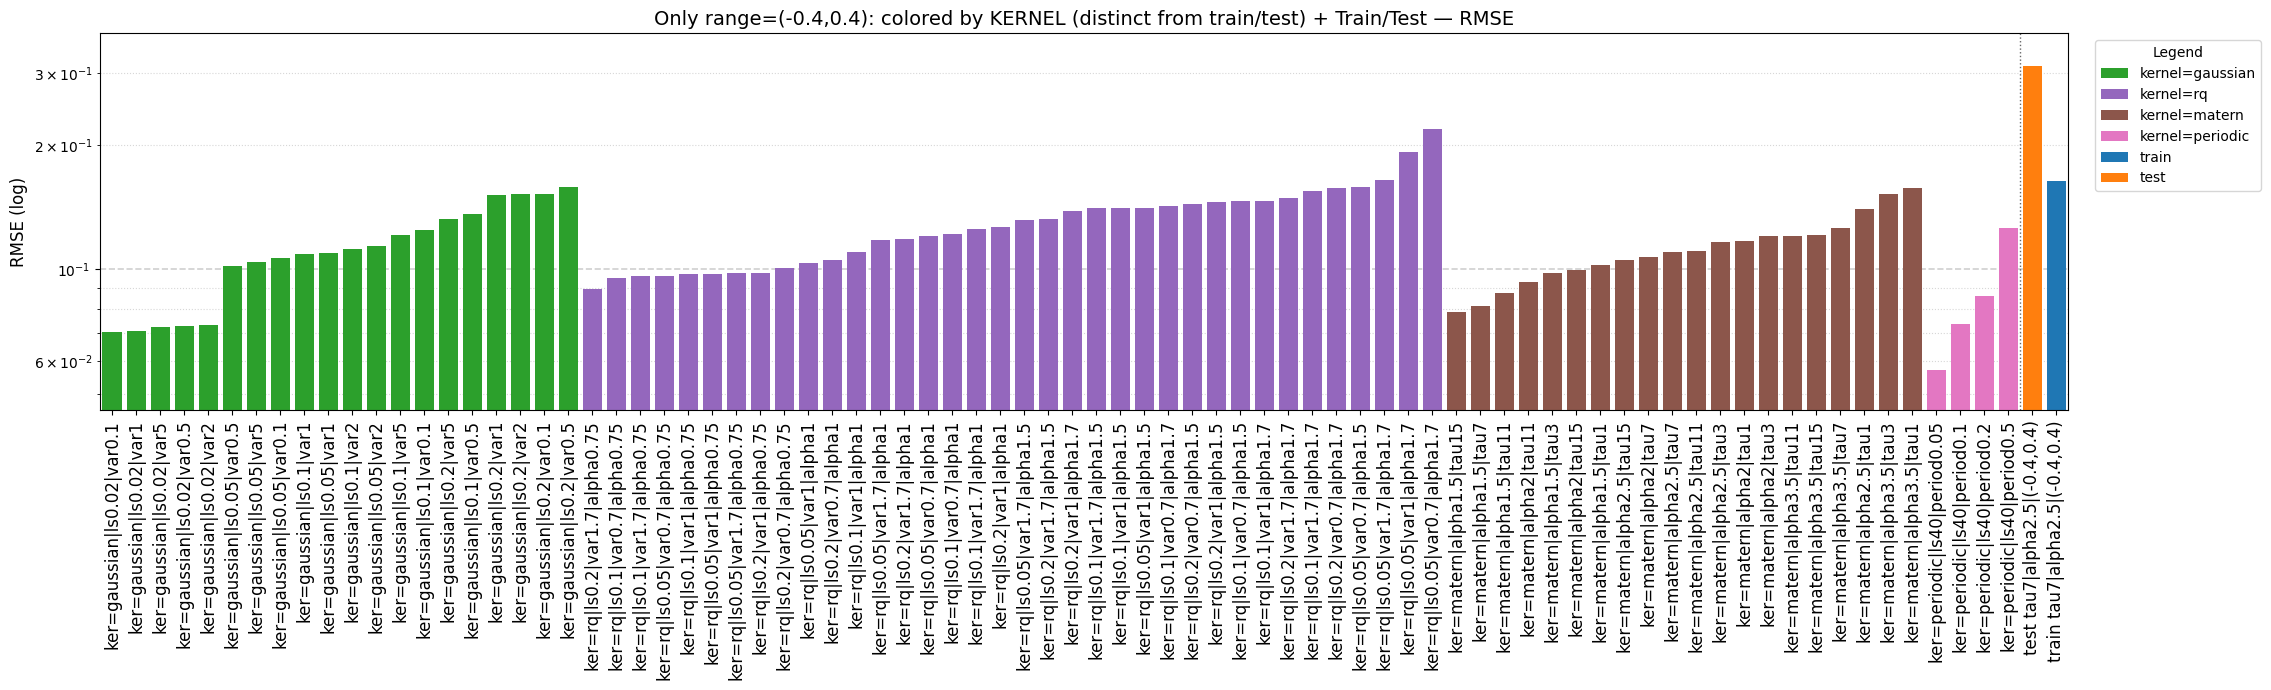

In [3]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 不要换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_params_label(row):
    """按 kernel 拼接单行参数标签（不包含 'GRF'；range 此处省略，因全为(-0.4,0.4)）"""
    k = row["kernel"]
    name = str(row.get("dataset_name", "")).lower()

    # 兜底提取
    def grab(pat):
        m = re.search(pat, name)
        return m.group(1) if m else None

    if k == "matern":
        alpha = row.get("alpha"); tau = row.get("tau", None)
        if (pd.isna(alpha) or alpha == "" or alpha is None):
            alpha = grab(r"alpha([0-9eE\.\-]+)")
        if (pd.isna(tau) or tau == "" or tau is None):
            tau = grab(r"tau([0-9eE\.\-]+)")
        return f"ker=matern|alpha{fmt_float(alpha)}|tau{fmt_float(tau)}"
    elif k == "gaussian":
        ls = row.get("length_scale"); var = row.get("variance")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(var) or var == "" or var is None):
            var = grab(r"variance([0-9eE\.\-]+)")
        return f"ker=gaussian|ls{fmt_float(ls)}|var{fmt_float(var)}"
    elif k == "rq":
        ls = row.get("length_scale"); var = row.get("variance"); alpha = row.get("alpha")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(var) or var == "" or var is None):
            var = grab(r"variance([0-9eE\.\-]+)")
        if (pd.isna(alpha) or alpha == "" or alpha is None):
            alpha = grab(r"alpha([0-9eE\.\-]+)")
        return f"ker=rq|ls{fmt_float(ls)}|var{fmt_float(var)}|alpha{fmt_float(alpha)}"
    elif k == "periodic":
        ls = row.get("length_scale"); period = row.get("period")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(period) or period == "" or period is None):
            period = grab(r"period([0-9eE\.\-]+)")
        return f"ker=periodic|ls{fmt_float(ls)}|period{fmt_float(period)}"
    else:
        return f"ker={k}"

# ---------- 读 generalizability CSV -> 只保留 family=GRF 且 range=(-0.4,0.4) ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)

# 关键：只保留 (-0.4, 0.4)
mask_range = (
    pd.to_numeric(df_grf.get("vmin"), errors="coerce").sub(-0.4).abs().lt(1e-8) &
    pd.to_numeric(df_grf.get("vmax"), errors="coerce").sub( 0.4).abs().lt(1e-8)
)
df_grf = df_grf[(df_grf["family"] == "GRF") & mask_range].copy()

# 每根柱子的单行标签（不写 GRF、也不写 range，因为都是同一范围）
df_grf["bar_label"] = df_grf.apply(get_params_label, axis=1)

# ---------- 颜色：kernel -> 一套不与 train/test 冲突的色盘 ----------
kernel_order = ["gaussian", "rq", "matern", "periodic", "rbf", "other"]
# 选用一组与 train/test(蓝/橙)明显区分的颜色：绿/紫/棕/粉/青/灰/橄榄
kernel_color_cycle = ["#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#17becf", "#7f7f7f", "#bcbd22"]

present_kernels = [k for k in kernel_order if k in set(df_grf["kernel"])]
kernel2color = {k: kernel_color_cycle[i % len(kernel_color_cycle)] for i, k in enumerate(present_kernels)}

def color_by_kernel(row):
    return kernel2color.get(row["kernel"], "#555555")

# 排序：kernel -> rmse
df_grf = (
    df_grf.assign(__sort=df_grf.apply(lambda r: (kernel_order.index(r["kernel"]) if r["kernel"] in kernel_order else 999,
                                                 float(r["rmse_mean"]) if pd.notna(r["rmse_mean"]) else np.inf), axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True)
)

# ---------- 读 train/test CSV -> 两条 baseline（追加到最后） ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# baseline 标签
df_base["bar_label"] = df_base["split"].map({"train": TRAIN_DESC, "test": TEST_DESC})
df_base["kernel"] = "baseline"
df_base["__is_baseline"] = True
df_grf["__is_baseline"] = False

# 合并：先所有 GRF（-0.4,0.4），最后接 baseline 两根柱
df_all = pd.concat([df_grf, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图（单轴，所有柱都带标签） ----------
fig_w = max(24, int(len(df_all) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# train/test 用固定蓝/橙；kernel 用上面另一套颜色
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}  # 与 kernel 色分离
colors = []
for _, r in df_all.iterrows():
    if r.get("__is_baseline", False):
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_kernel(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：GRF 段 与 baseline 段之间
baseline_start = len(df_grf)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("Only range=(-0.4,0.4): colored by KERNEL (distinct from train/test) + Train/Test — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 每根柱都显示“单行”标签（不换行）
labels = df_all["bar_label"].tolist()
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=12)

# 图例：kernel 色 & baseline（蓝/橙）
legend_elements = []
for k in present_kernels:
    legend_elements.append(Patch(facecolor=kernel2color[k], edgecolor="none", label=f"kernel={k}"))
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_kernel_colors_distinct_from_train_test.png", dpi=200, bbox_inches="tight")



/tmp/ipykernel_934028/3911762550.py:135: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


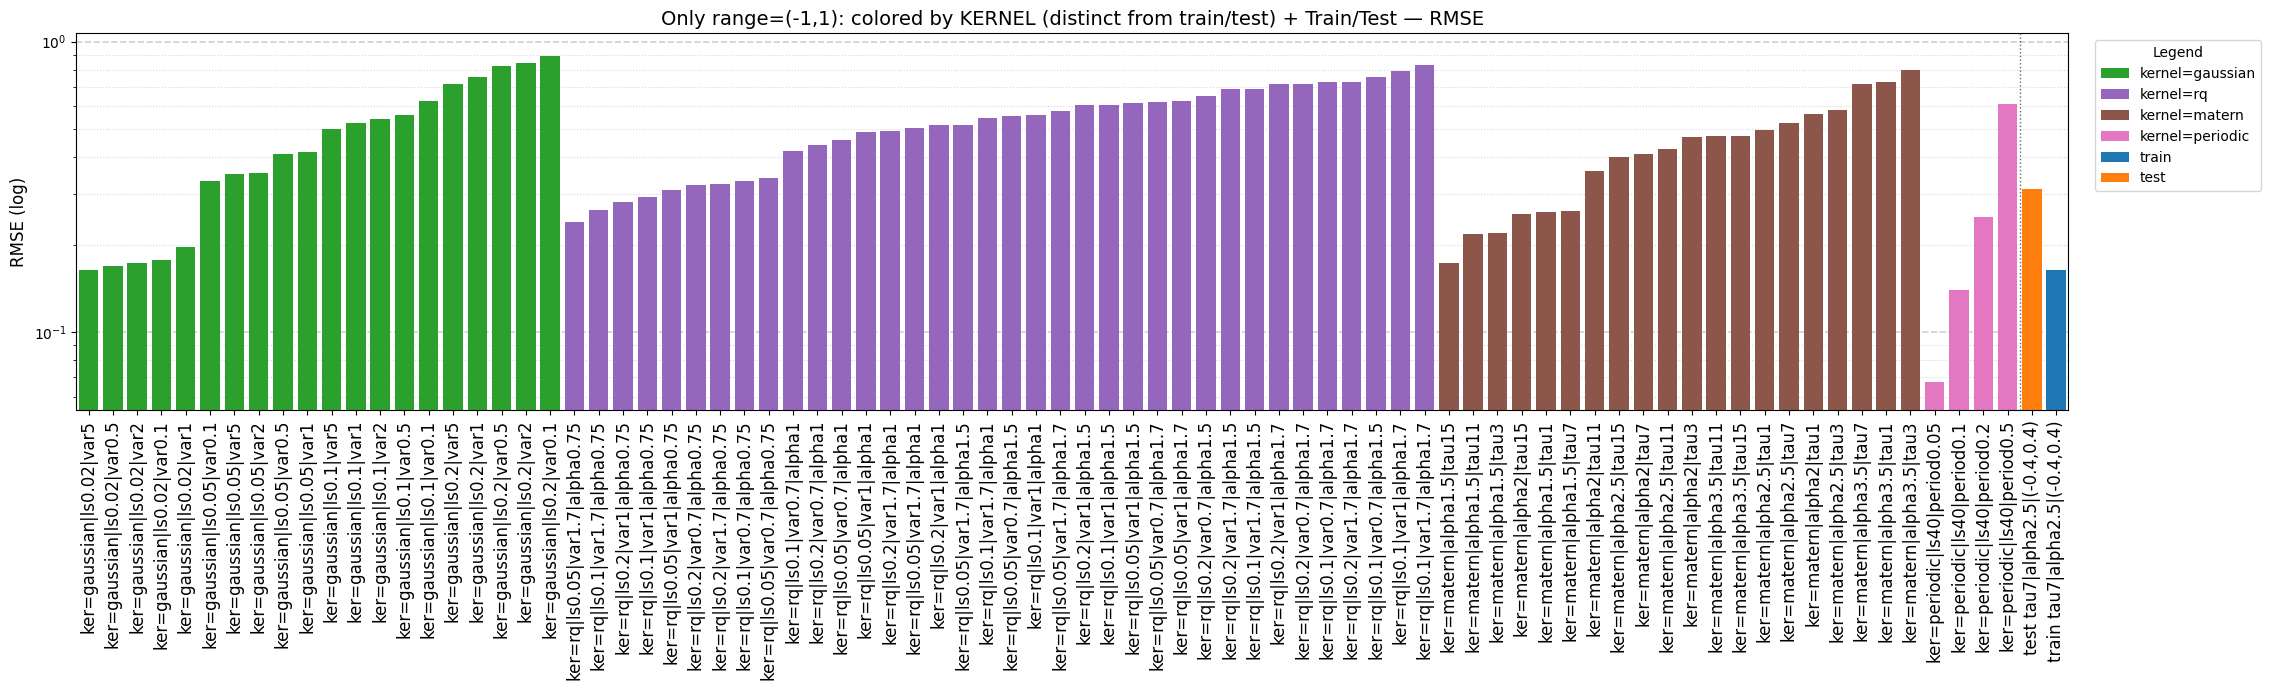

In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# （可改）给 train/test 的单行描述 —— 不要换行即可
TRAIN_DESC = "train tau7|alpha2.5|(-0.4,0.4)"
TEST_DESC  = "test tau7|alpha2.5|(-0.4,0.4)"

# ---------- 通用解析：抽取 (family, kernel) ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

def get_params_label(row):
    """按 kernel 拼接单行参数标签（不包含 'GRF'；range 此处省略，因全为(-0.4,0.4)）"""
    k = row["kernel"]
    name = str(row.get("dataset_name", "")).lower()

    # 兜底提取
    def grab(pat):
        m = re.search(pat, name)
        return m.group(1) if m else None

    if k == "matern":
        alpha = row.get("alpha"); tau = row.get("tau", None)
        if (pd.isna(alpha) or alpha == "" or alpha is None):
            alpha = grab(r"alpha([0-9eE\.\-]+)")
        if (pd.isna(tau) or tau == "" or tau is None):
            tau = grab(r"tau([0-9eE\.\-]+)")
        return f"ker=matern|alpha{fmt_float(alpha)}|tau{fmt_float(tau)}"
    elif k == "gaussian":
        ls = row.get("length_scale"); var = row.get("variance")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(var) or var == "" or var is None):
            var = grab(r"variance([0-9eE\.\-]+)")
        return f"ker=gaussian|ls{fmt_float(ls)}|var{fmt_float(var)}"
    elif k == "rq":
        ls = row.get("length_scale"); var = row.get("variance"); alpha = row.get("alpha")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(var) or var == "" or var is None):
            var = grab(r"variance([0-9eE\.\-]+)")
        if (pd.isna(alpha) or alpha == "" or alpha is None):
            alpha = grab(r"alpha([0-9eE\.\-]+)")
        return f"ker=rq|ls{fmt_float(ls)}|var{fmt_float(var)}|alpha{fmt_float(alpha)}"
    elif k == "periodic":
        ls = row.get("length_scale"); period = row.get("period")
        if (pd.isna(ls) or ls == "" or ls is None):
            ls = grab(r"length_scale([0-9eE\.\-]+)")
        if (pd.isna(period) or period == "" or period is None):
            period = grab(r"period([0-9eE\.\-]+)")
        return f"ker=periodic|ls{fmt_float(ls)}|period{fmt_float(period)}"
    else:
        return f"ker={k}"

# ---------- 读 generalizability CSV -> 只保留 family=GRF 且 range=(-0.4,0.4) ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)

# 关键：只保留 (-0.4, 0.4)
mask_range = (
    pd.to_numeric(df_grf.get("vmin"), errors="coerce").sub(-1).abs().lt(1e-8) &
    pd.to_numeric(df_grf.get("vmax"), errors="coerce").sub(1).abs().lt(1e-8)
)
df_grf = df_grf[(df_grf["family"] == "GRF") & mask_range].copy()

# 每根柱子的单行标签（不写 GRF、也不写 range，因为都是同一范围）
df_grf["bar_label"] = df_grf.apply(get_params_label, axis=1)

# ---------- 颜色：kernel -> 一套不与 train/test 冲突的色盘 ----------
kernel_order = ["gaussian", "rq", "matern", "periodic", "rbf", "other"]
# 选用一组与 train/test(蓝/橙)明显区分的颜色：绿/紫/棕/粉/青/灰/橄榄
kernel_color_cycle = ["#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#17becf", "#7f7f7f", "#bcbd22"]

present_kernels = [k for k in kernel_order if k in set(df_grf["kernel"])]
kernel2color = {k: kernel_color_cycle[i % len(kernel_color_cycle)] for i, k in enumerate(present_kernels)}

def color_by_kernel(row):
    return kernel2color.get(row["kernel"], "#555555")

# 排序：kernel -> rmse
df_grf = (
    df_grf.assign(__sort=df_grf.apply(lambda r: (kernel_order.index(r["kernel"]) if r["kernel"] in kernel_order else 999,
                                                 float(r["rmse_mean"]) if pd.notna(r["rmse_mean"]) else np.inf), axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True)
)

# ---------- 读 train/test CSV -> 两条 baseline（追加到最后） ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")
df_base = df_base.sort_values(by="split").reset_index(drop=True)

# baseline 标签
df_base["bar_label"] = df_base["split"].map({"train": TRAIN_DESC, "test": TEST_DESC})
df_base["kernel"] = "baseline"
df_base["__is_baseline"] = True
df_grf["__is_baseline"] = False

# 合并：先所有 GRF（-0.4,0.4），最后接 baseline 两根柱
df_all = pd.concat([df_grf, df_base], ignore_index=True)

# ---------- 统一 y 轴范围（log） ----------
rmse_vals = pd.to_numeric(df_all["rmse_mean"], errors="coerce")
rmse_vals = rmse_vals[(rmse_vals > 0)].dropna()
ymin_plot = (rmse_vals.min() * 0.8) if len(rmse_vals) else 1e-3
ymax_plot = (rmse_vals.max() * 1.2) if len(rmse_vals) else 1.0

# ---------- 画图（单轴，所有柱都带标签） ----------
fig_w = max(24, int(len(df_all) * 0.095))
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = np.arange(len(df_all))
y = pd.to_numeric(df_all["rmse_mean"], errors="coerce").to_numpy(float)

# train/test 用固定蓝/橙；kernel 用上面另一套颜色
base_color_map = {"train": "#1f77b4", "test": "#ff7f0e"}  # 与 kernel 色分离
colors = []
for _, r in df_all.iterrows():
    if r.get("__is_baseline", False):
        colors.append(base_color_map.get(r.get("split","other"), "#999999"))
    else:
        colors.append(color_by_kernel(r))

bars = ax.bar(x, y, color=colors, edgecolor="none")

# 分隔线：GRF 段 与 baseline 段之间
baseline_start = len(df_grf)
if baseline_start < len(df_all):
    ax.axvline(baseline_start - 0.5, color="black", lw=1.0, ls=":", alpha=0.6)

# 横向网格
ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linestyle='--', linewidth=1.2, alpha=0.6)
ax.grid(axis='y', which='minor', linestyle=':',  linewidth=0.8, alpha=0.5)

# 轴设定
ax.set_yscale("log")
ax.set_ylim(ymin_plot, ymax_plot)
ax.set_xlim(-0.5, len(df_all) - 0.5 if len(df_all) else 0.5)
ax.set_title("Only range=(-1,1): colored by KERNEL (distinct from train/test) + Train/Test — RMSE", fontsize=14)
ax.set_ylabel("RMSE (log)", fontsize=12)

# 每根柱都显示“单行”标签（不换行）
labels = df_all["bar_label"].tolist()
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=12)

# 图例：kernel 色 & baseline（蓝/橙）
legend_elements = []
for k in present_kernels:
    legend_elements.append(Patch(facecolor=kernel2color[k], edgecolor="none", label=f"kernel={k}"))
legend_elements.append(Patch(facecolor=base_color_map["train"], edgecolor="none", label="train"))
legend_elements.append(Patch(facecolor=base_color_map["test"],  edgecolor="none", label="test"))
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Legend")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
# 如需保存：plt.savefig("rmse_kernel_colors_distinct_from_train_test.png", dpi=200, bbox_inches="tight")




In [13]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===== 改成你的路径 =====
CSV_GRF  = "generalizability_results/csv/SUMMARY__Tin10_Tout10.csv"
CSV_BASE = "test_train_results/csv/SUMMARY__Tin10_Tout10.csv"

# ---------- 通用解析：抽取 (family, kernel) 与 range ----------
def extract_family_kernel(row):
    txts = []
    for key in ("type", "dataset_name"):
        v = row.get(key, None)
        if isinstance(v, str):
            txts.append(v)
    txt = " ".join(txts).lower()

    # family
    if "negloggrf" in txt:
        family = "NegLogGRF"
    elif "loggrf" in txt:
        family = "LogGRF"
    elif "grf" in txt:
        family = "GRF"
    else:
        family = "other"

    # kernel（多路兜底）
    kernel_raw = None
    m = re.search(r"kernel\s*=\s*([a-z0-9_]+)", txt)
    if m:
        kernel_raw = m.group(1)
    if not kernel_raw:
        m = re.search(r"(?:negloggrf|loggrf|grf)[\-_]?([a-z0-9]+)", txt)
        if m:
            kernel_raw = m.group(1)
    if not kernel_raw:
        for kw in [
            "matern", "periodic", "gaussian", "rbf", "rq",
            "rational_quadratic","rationalquadratic",
            "se","sqexp","squared_exponential","squaredexponential",
            "gauss","exp_quadratic","expquadratic"
        ]:
            if kw in txt:
                kernel_raw = kw
                break

    def canon(k):
        if not k:
            return "other"
        k = k.lower()
        if k in {"gauss","gaussian","rbf","se","sqexp","squared_exponential",
                 "squaredexponential","exp_quadratic","expquadratic"}:
            return "gaussian"
        if k in {"rq","rational_quadratic","rationalquadratic"}:
            return "rq"
        return k

    kernel = canon(kernel_raw)
    return pd.Series({"family": family, "kernel": kernel})

def fmt_float(v):
    if pd.isna(v):
        return "?"
    try:
        return f"{float(v):.6g}"
    except Exception:
        return str(v)

def build_range_label(row):
    vmin = row.get("vmin", np.nan)
    vmax = row.get("vmax", np.nan)
    if pd.isna(vmin) or pd.isna(vmax):
        return "range=unknown"
    lo, hi = float(vmin), float(vmax)
    if lo > hi:
        lo, hi = hi, lo
    return f"range=({fmt_float(lo)},{fmt_float(hi)})"

# ---------- 读 GRF CSV -> 只保留 family=GRF ----------
df_grf = pd.read_csv(CSV_GRF)
for col in df_grf.columns:
    if col in ["dataset_name", "dataset_path", "type", "solver"]:
        continue
    df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")

df_grf[["family","kernel"]] = df_grf.apply(extract_family_kernel, axis=1)
df_grf["range_label"] = df_grf.apply(build_range_label, axis=1)
df_grf = df_grf[df_grf["family"] == "GRF"].copy()

# 排序：kernel -> range -> rmse
kernel_order = ["gaussian", "rbf", "rq", "matern", "periodic", "other"]
all_ranges = df_grf["range_label"].dropna().unique().tolist()
range_order  = all_ranges

def sort_key(row):
    k = row["kernel"]
    r = row["range_label"]
    ko = kernel_order.index(k) if k in kernel_order else len(kernel_order)
    ro = range_order.index(r) if r in range_order else len(range_order)
    rmse = float(row["rmse_mean"]) if pd.notna(row["rmse_mean"]) else np.inf
    return (ko, ro, rmse)

df_grf = (
    df_grf.assign(__sort=df_grf.apply(sort_key, axis=1))
          .sort_values(by="__sort", kind="mergesort")
          .drop(columns="__sort")
          .reset_index(drop=True)
)

# 颜色：range -> 色相
palette = plt.cm.Set2.colors if len(all_ranges) <= 8 else plt.cm.tab20.colors
range2color = {rg: palette[i % len(palette)] for i, rg in enumerate(all_ranges)}
def color_by_range(row):
    return range2color.get(row["range_label"], (0.7, 0.7, 0.7))

# 纹理：kernel -> hatch
hatch_map = {
    "gaussian": "-",
    "rbf": ".",
    "rq": "\\",
    "matern": "/",
    "periodic": "x",
    "other": None,
}

# ---------- 读 train/test CSV -> 取两条 baseline ----------
df_base = pd.read_csv(CSV_BASE)
need_cols = ["dataset_name","rmse_mean","N"]
for c in need_cols:
    if c not in df_base.columns:
        raise ValueError(f"CSV缺少列: {c}")

def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name or re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if "_test_"  in name or re.search(r"(?:^|_)test(?:_|$)",  name):
        return "test"
    return "other"

df_base["split"] = df_base["dataset_name"].apply(parse_split)
df_base = df_base[df_base["split"].isin(["train","test"])].copy()

# 只要 rmse_mean 与 N
df_base["rmse_mean"] = pd.to_numeric(df_base["rmse_mean"], errors="coerce")
df_base["N"] = pd.to_numeric(df_base["N"], errors="coerce")

# 构造与 GRF 相同的列接口（占位）
df_base["kernel"] = "baseline"
df_base["range_label"] = "baseline"
df_base["__is_baseline"] = True
df_grf["__is_baseline"] = False

# 合并：GRF 在前，baseline 两根柱接在最后
df_all = pd.concat([df_grf, df_base], ignore_index=True)
# --- 1) 取 baseline 的 train/test RMSE ---
# 需要 df_all 里有两行 baseline：__is_baseline==True 且 split in {"train","test"}
base_df = df_all[df_all.get("__is_baseline", False) == True].copy()

if base_df.empty or not set(base_df["split"]).issuperset({"train","test"}):
    raise RuntimeError("df_all 里找不到 baseline 行（__is_baseline=True 且 split=train/test）。")

train_rmse = float(pd.to_numeric(base_df.loc[base_df["split"]=="train","rmse_mean"]).iloc[0])
test_rmse  = float(pd.to_numeric(base_df.loc[base_df["split"]=="test", "rmse_mean"]).iloc[0])

# --- 2) 候选集：去掉 baseline，只看一般化评估那部分 ---
cand = df_all[df_all.get("__is_baseline", False) == False].copy()
cand["rmse_mean"] = pd.to_numeric(cand["rmse_mean"], errors="coerce")

# --- 3) 分别过滤出 小于 train / 小于 test 的集合，并加入“差值”列 ---
lt_train = cand[cand["rmse_mean"] < train_rmse].copy()
lt_test  = cand[cand["rmse_mean"]  < test_rmse ].copy()

lt_train["Δ_vs_train"] = lt_train["rmse_mean"] - train_rmse
lt_test["Δ_vs_test"]   = lt_test["rmse_mean"]  - test_rmse

# --- 4) 选择“详细信息”列（存在才选，避免 KeyError）---
prefer_cols = [
    "dataset_name","dataset_path","rmse_mean","rmse_var","N",
    "family","kernel","range_label",
    "alpha","tau","length_scale","variance","period","exp_factor",
    "vmax","vmin","solver","nx","nu","t","ntimepoints"
]
detail_cols = [c for c in prefer_cols if c in cand.columns]

# 排序：按 rmse 从小到大
lt_train = lt_train.sort_values("rmse_mean")[detail_cols + (["Δ_vs_train"] if "Δ_vs_train" in lt_train.columns else [])]
lt_test  = lt_test .sort_values("rmse_mean")[detail_cols + (["Δ_vs_test"]  if "Δ_vs_test"  in lt_test.columns  else [])]

print(f"baseline: train RMSE={train_rmse:.6g}, test RMSE={test_rmse:.6g}")
print(f"严格小于 train 的数量: {len(lt_train)}")
print(f"严格小于 test  的数量: {len(lt_test)}")

# --- 5) 展示为表格（Jupyter 会直接渲染 DataFrame；命令行可用 print）---
display(lt_train)  # 若不在 Jupyter，把 display(...) 换成 print(lt_train.to_string(index=False))
display(lt_test)

# 如需保存：
# lt_train.to_csv("rows_rmse_lt_train.csv", index=False)
# lt_test.to_csv("rows_rmse_lt_test.csv", index=False)


/tmp/ipykernel_396648/1375751866.py:87: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_grf[col] = pd.to_numeric(df_grf[col], errors="ignore")


baseline: train RMSE=0.163577, test RMSE=0.311532
严格小于 train 的数量: 80
严格小于 test  的数量: 99


,dataset_name,dataset_path,rmse_mean,rmse_var,N,family,kernel,range_label,alpha,length_scale,variance,exp_factor,vmax,vmin,solver,nx,nu,t,ntimepoints,Δ_vs_train
460,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.056967,0.000016,10,GRF,periodic,"range=(-0.4,0.4)",NaN,40.00,NaN,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.106610
472,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.067328,0.000298,10,GRF,periodic,"range=(-1,1)",NaN,40.00,NaN,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.096249
20,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.070636,0.000050,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,0.1,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.092941
21,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.070801,0.000028,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,1.0,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.092776
22,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.072674,0.000096,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,5.0,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.090904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.157526,0.000690,10,GRF,rq,"range=(-0.4,0.4)",1.7,0.20,0.7,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.006051
375,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.157854,0.001059,10,GRF,matern,"range=(-0.4,0.4)",3.5,NaN,NaN,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.005723
188,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.158713,0.000556,10,GRF,rq,"range=(-0.4,0.4)",1.5,0.05,0.7,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.004864
39,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.158806,0.002385,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.20,0.5,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.004771


,dataset_name,dataset_path,rmse_mean,rmse_var,N,family,kernel,range_label,alpha,length_scale,variance,exp_factor,vmax,vmin,solver,nx,nu,t,ntimepoints,Δ_vs_test
460,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.056967,0.000016,10,GRF,periodic,"range=(-0.4,0.4)",NaN,40.00,NaN,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.254565
472,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.067328,0.000298,10,GRF,periodic,"range=(-1,1)",NaN,40.00,NaN,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.244204
20,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.070636,0.000050,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,0.1,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.240895
21,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.070801,0.000028,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,1.0,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.240731
22,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.072674,0.000096,10,GRF,gaussian,"range=(-0.4,0.4)",NaN,0.02,5.0,NaN,0.4,-0.4,exponax,256,0.0,20.0,21.0,-0.238858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.261254,0.009230,10,GRF,matern,"range=(-1,1)",1.50,NaN,NaN,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.050277
265,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.264164,0.009583,10,GRF,rq,"range=(-1,1)",0.75,0.10,1.7,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.047367
266,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.281478,0.010235,10,GRF,rq,"range=(-1,1)",0.75,0.20,1.0,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.030053
267,dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_t...,/blue/shiboli.fsu/yifeisun.umich/adversarial_r...,0.291438,0.010098,10,GRF,rq,"range=(-1,1)",0.75,0.10,1.0,NaN,1.0,-1.0,exponax,256,0.0,20.0,21.0,-0.020094


In [15]:
# 只取从 family 到 vmin 的参数列（两端都包含）
param_span = ["family","kernel","range_label","alpha","length_scale","variance","exp_factor","vmax","vmin"]

# 针对每个集合，按存在的列做一次取交集，避免缺列报错
cols_train = [c for c in param_span if c in lt_train.columns]
cols_test  = [c for c in param_span if c in lt_test.columns]

# 转成 list[tuple]
tuples_params_lt_train = [tuple(row[c] for c in cols_train) for _, row in lt_train.iterrows()]
tuples_params_lt_test  = [tuple(row[c] for c in cols_test)  for _, row in lt_test.iterrows()]

# 打印（先打印列顺序，后打印各 tuple）
print("\n=== 列顺序（lt_train，rmse < train_rmse）===")
print(cols_train)
print(f"=== 共 {len(tuples_params_lt_train)} 条 ===")
for t in tuples_params_lt_train:
    print(t)

print("\n=== 列顺序（lt_test，rmse < test_rmse）===")
print(cols_test)
print(f"=== 共 {len(tuples_params_lt_test)} 条 ===")
for t in tuples_params_lt_test:
    print(t)


=== 列顺序（lt_train，rmse < train_rmse）===
['family', 'kernel', 'range_label', 'alpha', 'length_scale', 'variance', 'exp_factor', 'vmax', 'vmin']
=== 共 80 条 ===
('GRF', 'periodic', 'range=(-0.4,0.4)', nan, 40.0, nan, nan, 0.4, -0.4)
('GRF', 'periodic', 'range=(-1,1)', nan, 40.0, nan, nan, 1.0, -1.0)
('GRF', 'gaussian', 'range=(-0.4,0.4)', nan, 0.02, 0.1, nan, 0.4, -0.4)
('GRF', 'gaussian', 'range=(-0.4,0.4)', nan, 0.02, 1.0, nan, 0.4, -0.4)
('GRF', 'gaussian', 'range=(-0.4,0.4)', nan, 0.02, 5.0, nan, 0.4, -0.4)
('GRF', 'gaussian', 'range=(-0.4,0.4)', nan, 0.02, 0.5, nan, 0.4, -0.4)
('GRF', 'gaussian', 'range=(-0.4,0.4)', nan, 0.02, 2.0, nan, 0.4, -0.4)
('GRF', 'periodic', 'range=(-0.4,0.4)', nan, 40.0, nan, nan, 0.4, -0.4)
('GRF', 'matern', 'range=(-0.4,0.4)', 1.5, nan, nan, nan, 0.4, -0.4)
('GRF', 'matern', 'range=(-0.4,0.4)', 1.5, nan, nan, nan, 0.4, -0.4)
('GRF', 'periodic', 'range=(-0.4,0.4)', nan, 40.0, nan, nan, 0.4, -0.4)
('GRF', 'matern', 'range=(-0.4,0.4)', 1.5, nan, nan, nan, 0.

In [16]:
# 只取从 family 到 vmin 的参数列（两端都包含）
param_span = ["family","kernel","range_label","alpha","length_scale","variance","exp_factor","vmax","vmin"]

def kv_tuples(df_sub):
    # 实际存在的列（避免缺列报错）
    cols = [c for c in param_span if c in df_sub.columns]

    def fmt_any(v):
        # NaN -> '?', 数字短格式，其它转字符串
        if pd.isna(v):
            return "?"
        try:
            return f"{float(v):.6g}"
        except Exception:
            return str(v)

    tuples_out = []
    for _, row in df_sub[cols].iterrows():
        tuples_out.append(tuple(f"{c}={fmt_any(row[c])}" for c in cols))
    return cols, tuples_out

# 分别生成并打印
cols_train, tuples_params_lt_train = kv_tuples(lt_train)
cols_test,  tuples_params_lt_test  = kv_tuples(lt_test)

print("\n=== 列顺序（带 key=，lt_train，rmse < train_rmse）===")
print(cols_train)
print(f"=== 共 {len(tuples_params_lt_train)} 条 ===")
for t in tuples_params_lt_train:
    print(t)

print("\n=== 列顺序（带 key=，lt_test，rmse < test_rmse）===")
print(cols_test)
print(f"=== 共 {len(tuples_params_lt_test)} 条 ===")
for t in tuples_params_lt_test:
    print(t)



=== 列顺序（带 key=，lt_train，rmse < train_rmse）===
['family', 'kernel', 'range_label', 'alpha', 'length_scale', 'variance', 'exp_factor', 'vmax', 'vmin']
=== 共 80 条 ===
('family=GRF', 'kernel=periodic', 'range_label=range=(-0.4,0.4)', 'alpha=?', 'length_scale=40', 'variance=?', 'exp_factor=?', 'vmax=0.4', 'vmin=-0.4')
('family=GRF', 'kernel=periodic', 'range_label=range=(-1,1)', 'alpha=?', 'length_scale=40', 'variance=?', 'exp_factor=?', 'vmax=1', 'vmin=-1')
('family=GRF', 'kernel=gaussian', 'range_label=range=(-0.4,0.4)', 'alpha=?', 'length_scale=0.02', 'variance=0.1', 'exp_factor=?', 'vmax=0.4', 'vmin=-0.4')
('family=GRF', 'kernel=gaussian', 'range_label=range=(-0.4,0.4)', 'alpha=?', 'length_scale=0.02', 'variance=1', 'exp_factor=?', 'vmax=0.4', 'vmin=-0.4')
('family=GRF', 'kernel=gaussian', 'range_label=range=(-0.4,0.4)', 'alpha=?', 'length_scale=0.02', 'variance=5', 'exp_factor=?', 'vmax=0.4', 'vmin=-0.4')
('family=GRF', 'kernel=gaussian', 'range_label=range=(-0.4,0.4)', 'alpha=?', 'le